In [70]:
!pip install zarr folium

In [71]:
import pandas as pd
import time
import numpy as np
import zarr
import os
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import matplotlib.dates as mdates
from dask.diagnostics import ProgressBar
import folium

In [60]:
ruta_fuentes = "/kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes"
ruta_modis = "/kaggle/input/datasets/edwardsx/modis-v2-panel"
ruta_dagma = "/kaggle/input/datasets/edwardsx/dagma-cristian-2021-2025-combinado"
ruta_tiles = "/kaggle/input/datasets/edwardsx/geovision-tiles-sit2"

In [4]:
sns.set_theme(style="whitegrid")

# DAGMA

In [5]:
df_dagma = pd.read_parquet(
    os.path.join(ruta_dagma, "df_cristian_dagma_2021_2025.parquet"))

In [6]:
df_dagma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379535 entries, 0 to 379534
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   nombre_est     379535 non-null  object        
 1   tipo_gas       379535 non-null  object        
 2   concentracion  379535 non-null  float64       
 3   fecha          379535 non-null  datetime64[us]
 4   fuente         379535 non-null  object        
 5   estacion_id    379535 non-null  int64         
 6   latitud        379535 non-null  float64       
 7   longitud       379535 non-null  float64       
 8   altitud        379535 non-null  float64       
 9   municipio      379535 non-null  object        
dtypes: datetime64[us](1), float64(4), int64(1), object(4)
memory usage: 29.0+ MB


In [7]:
df_dagma.head()

,nombre_est,tipo_gas,concentracion,fecha,fuente,estacion_id,latitud,longitud,altitud,municipio
0,base aerea,o3,7.258768,2021-01-01 00:00:00,cristian,8285,3.457128,-76.502303,956.0,santiago de cali
1,canaveralejo,so2,2.147011,2021-01-01 00:00:00,cristian,30109,3.411100,-76.544400,975.0,santiago de cali
2,compartir,o3,1.020151,2021-01-01 00:00:00,cristian,30110,3.425800,-76.474100,960.0,santiago de cali
3,estacion yumbo,no2,6.170000,2021-01-01 00:00:00,cvc,8777,3.579075,-76.489558,950.0,yumbo
4,base aerea,o3,13.163875,2021-01-01 01:00:00,cristian,8285,3.457128,-76.502303,956.0,santiago de cali


In [8]:
df_dagma["concentracion"].describe().round(2)

count    379535.00
mean         13.61
std          17.59
min           0.00
25%           2.75
50%           6.96
75%          15.64
max          86.77
Name: concentracion, dtype: float64

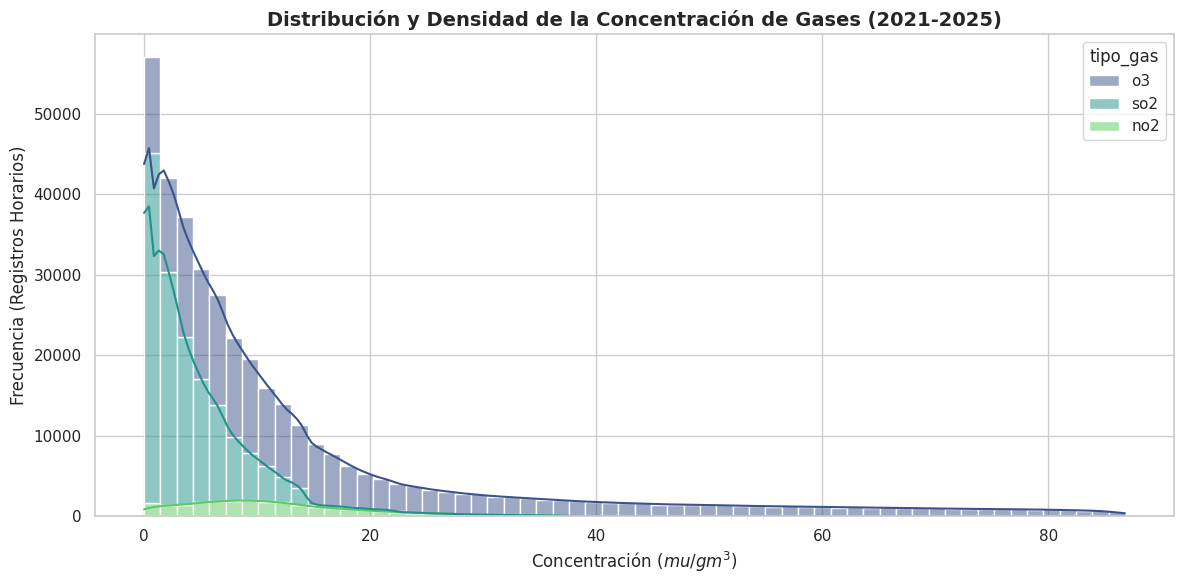

In [9]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_dagma,
    x="concentracion",
    hue="tipo_gas",
    kde=True,
    multiple="stack",
    bins=60,
    palette="viridis",
)

plt.title("Distribución y Densidad de la Concentración de Gases (2021-2025)", fontsize=14, fontweight="bold")
plt.xlabel("Concentración ($mu/gm^3$)")
plt.ylabel("Frecuencia (Registros Horarios)")
plt.tight_layout()
plt.show()

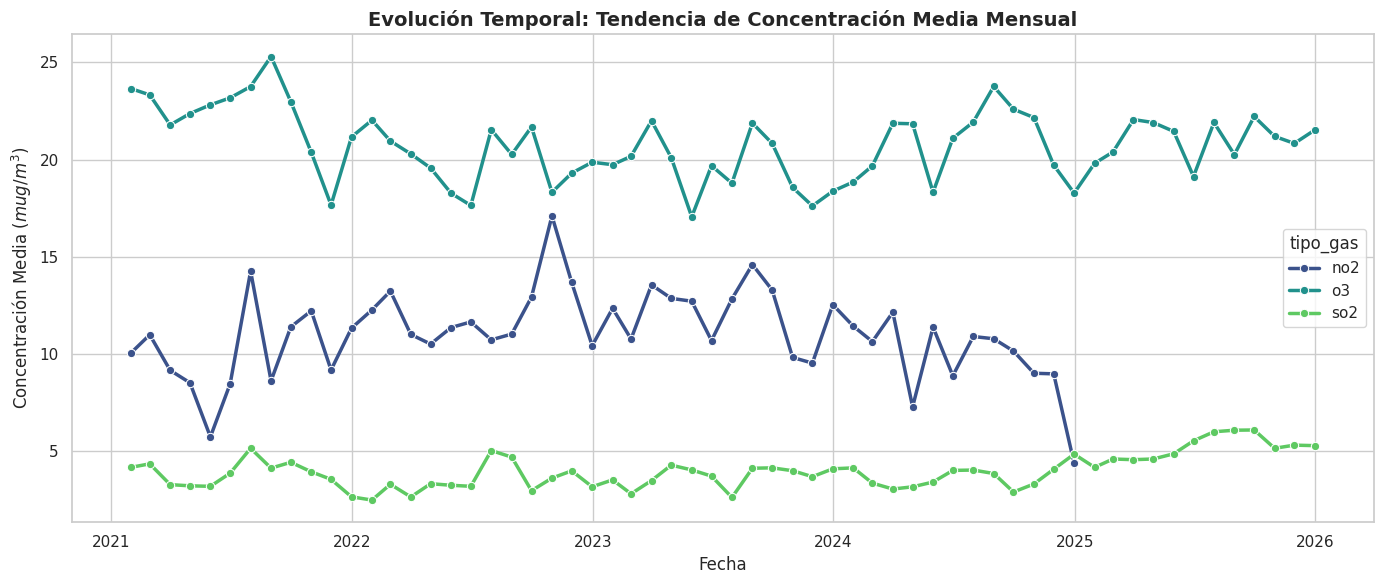

In [10]:
df_mensual = df_dagma.groupby([pd.Grouper(key="fecha", freq="ME"), "tipo_gas"])["concentracion"].mean().reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_mensual,
    x="fecha",
    y="concentracion",
    hue="tipo_gas",
    linewidth=2.5,
    marker="o",
    palette="viridis",
)

plt.title("Evolución Temporal: Tendencia de Concentración Media Mensual", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Concentración Media ($mu g/m^3$)")
plt.tight_layout()
plt.show()

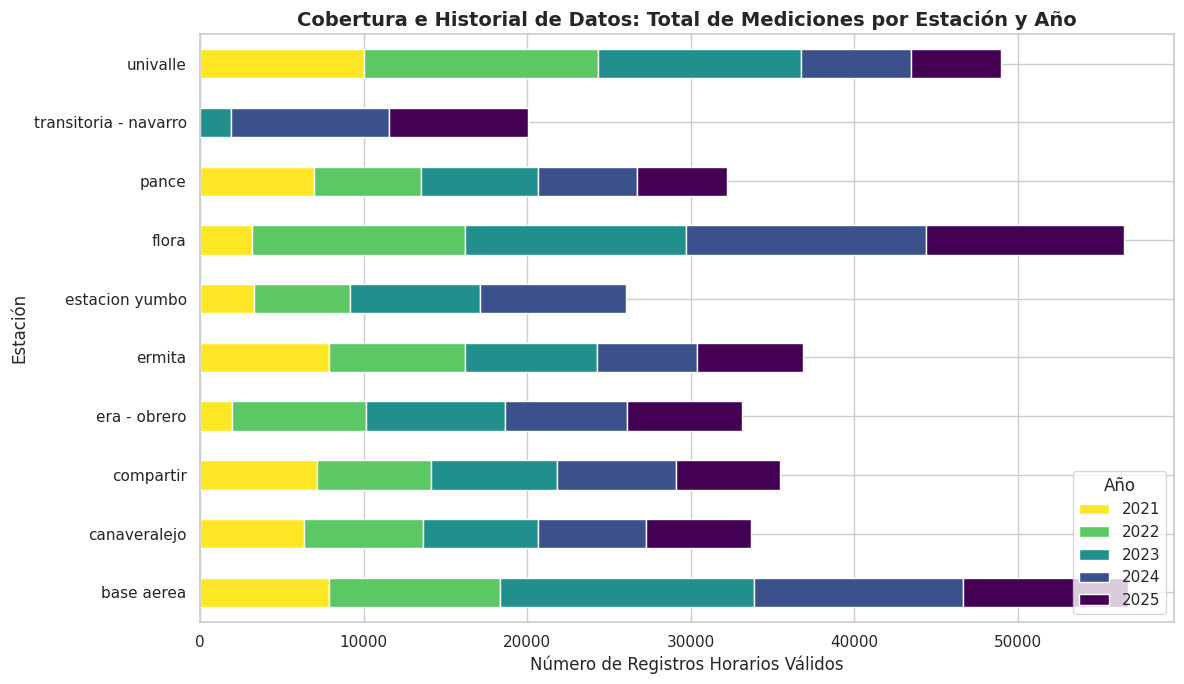

In [11]:
df_cobertura = df_dagma.groupby(["nombre_est", df_dagma["fecha"].dt.year])["concentracion"].count().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
ax = plt.gca()

df_cobertura.plot(kind="barh", stacked=True, ax=ax, cmap="viridis_r")

plt.title("Cobertura e Historial de Datos: Total de Mediciones por Estación y Año", fontsize=14, fontweight="bold")
plt.xlabel("Número de Registros Horarios Válidos")
plt.ylabel("Estación")
plt.legend(title="Año", loc="lower right")
plt.tight_layout()
plt.show()

VEMOS QUE LA COBERTURA NO DA PARA TRABAJAR BIEN

TRABAJAREMOS 4 AÑOS (2021 A 2024)

Y TRANSITORIA NAVARRO LA ELIMINAMOS PORQUE NO CUBRE BIEN LOS PUNTOS QUE NECESITAMOS

In [12]:
df_dagma = pd.read_parquet(
    os.path.join(ruta_dagma, "df_cristian_dagma_2021_2024_final.parquet"))

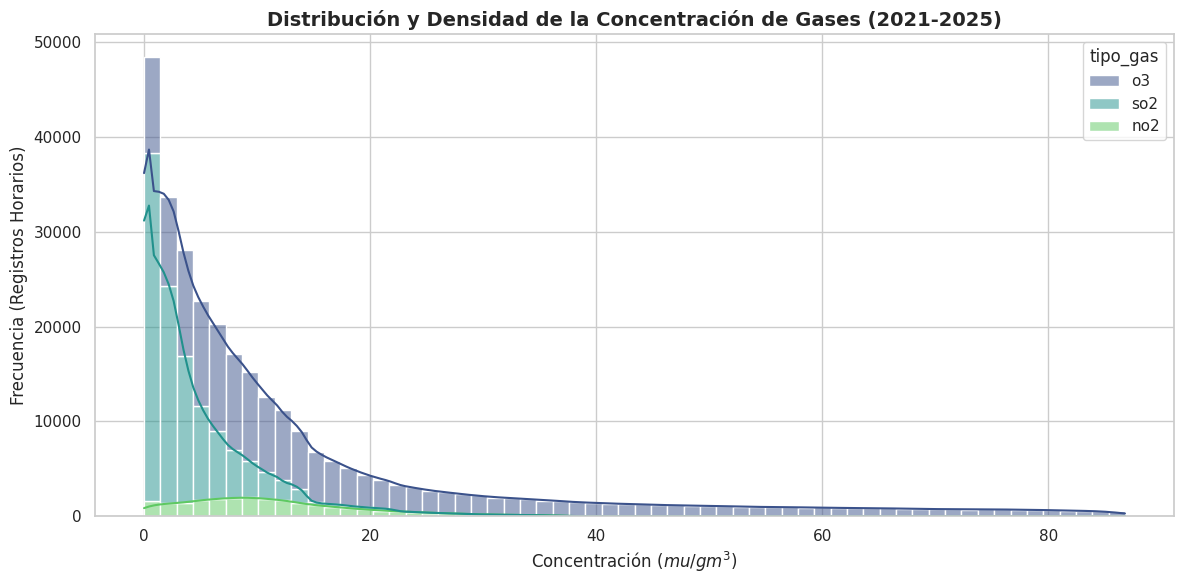

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_dagma,
    x="concentracion",
    hue="tipo_gas",
    kde=True,
    multiple="stack",
    bins=60,
    palette="viridis",
)

plt.title("Distribución y Densidad de la Concentración de Gases (2021-2025)", fontsize=14, fontweight="bold")
plt.xlabel("Concentración ($mu/gm^3$)")
plt.ylabel("Frecuencia (Registros Horarios)")
plt.tight_layout()
plt.show()

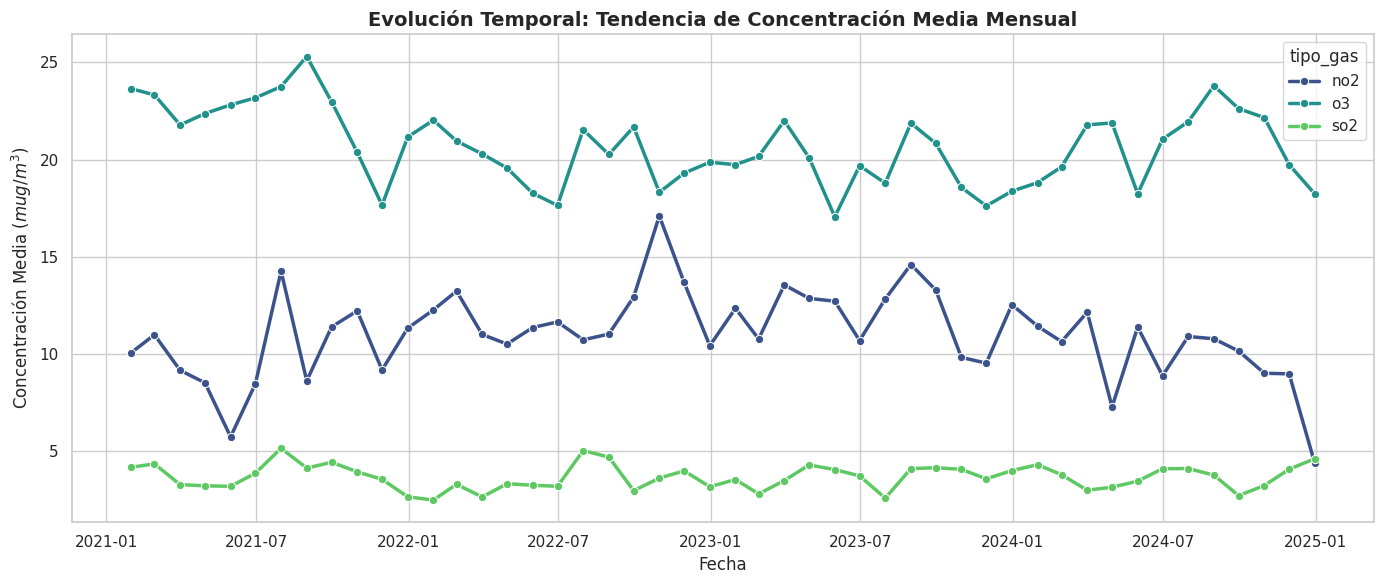

In [14]:
df_mensual = df_dagma.groupby([pd.Grouper(key="fecha", freq="ME"), "tipo_gas"])["concentracion"].mean().reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_mensual,
    x="fecha",
    y="concentracion",
    hue="tipo_gas",
    linewidth=2.5,
    marker="o",
    palette="viridis",
)

plt.title("Evolución Temporal: Tendencia de Concentración Media Mensual", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Concentración Media ($mu g/m^3$)")
plt.tight_layout()
plt.show()

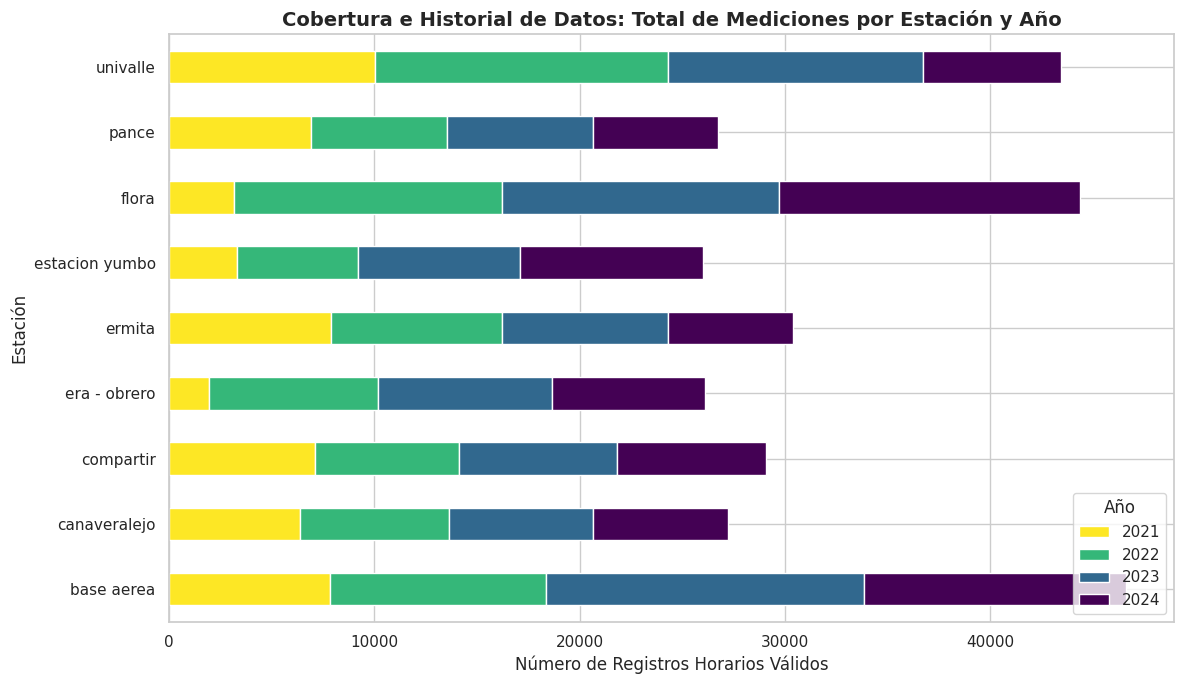

In [15]:
df_cobertura = df_dagma.groupby(["nombre_est", df_dagma["fecha"].dt.year])["concentracion"].count().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
ax = plt.gca()

df_cobertura.plot(kind="barh", stacked=True, ax=ax, cmap="viridis_r")

plt.title("Cobertura e Historial de Datos: Total de Mediciones por Estación y Año", fontsize=14, fontweight="bold")
plt.xlabel("Número de Registros Horarios Válidos")
plt.ylabel("Estación")
plt.legend(title="Año", loc="lower right")
plt.tight_layout()
plt.show()

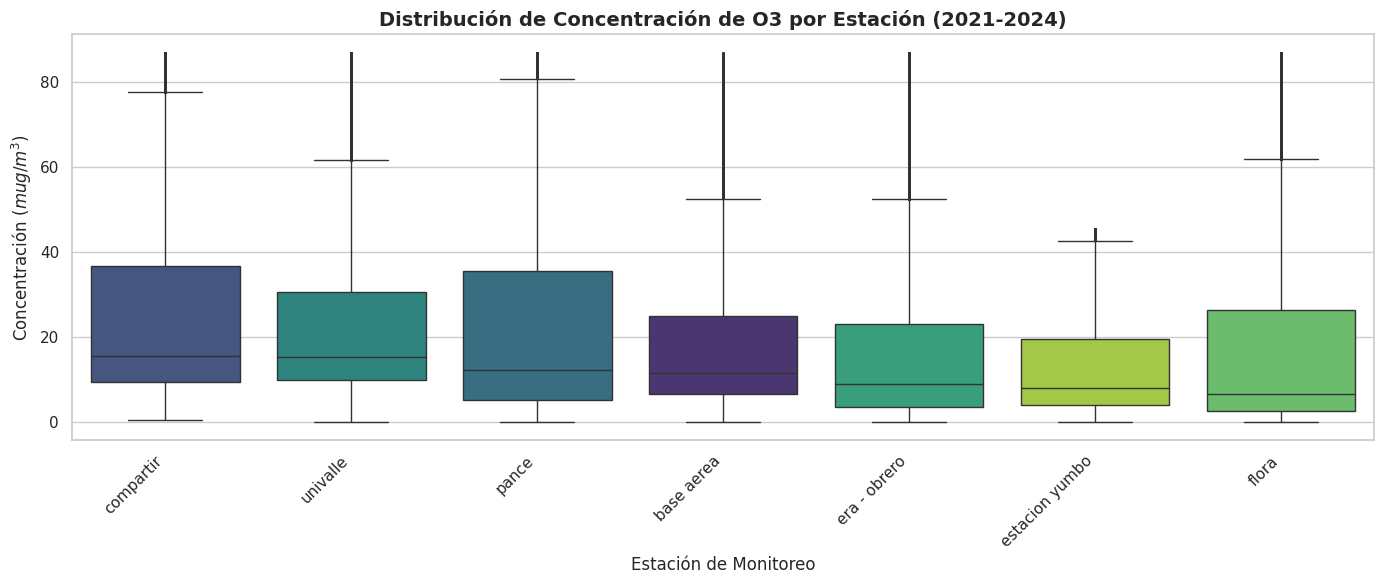

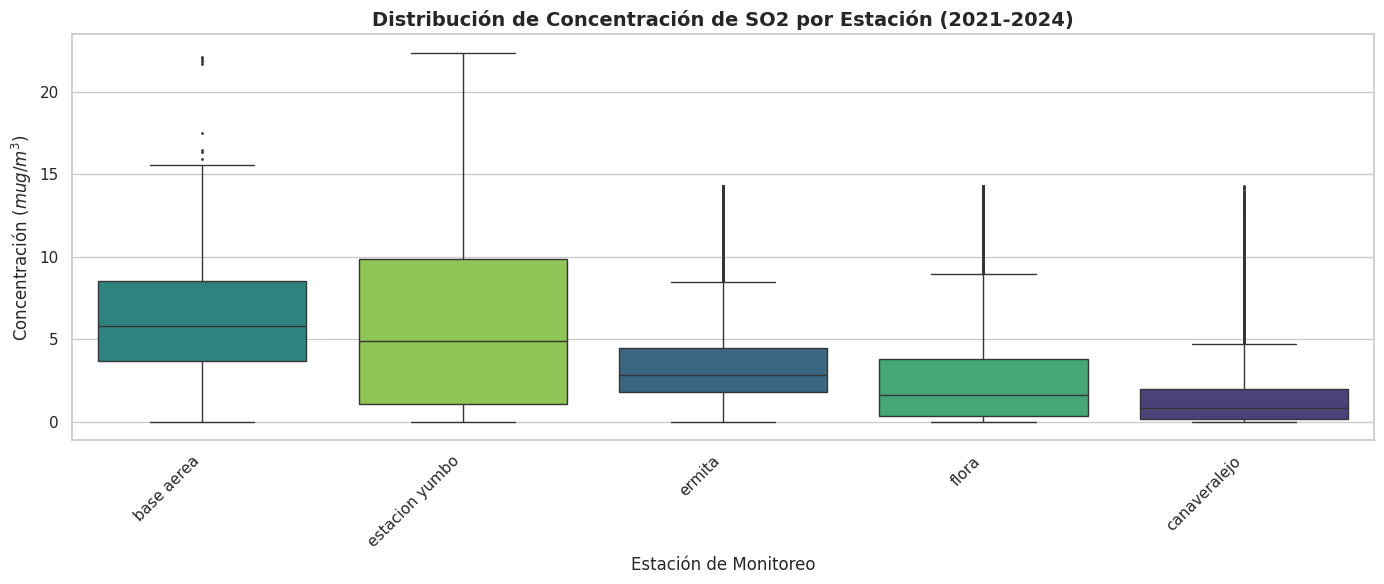

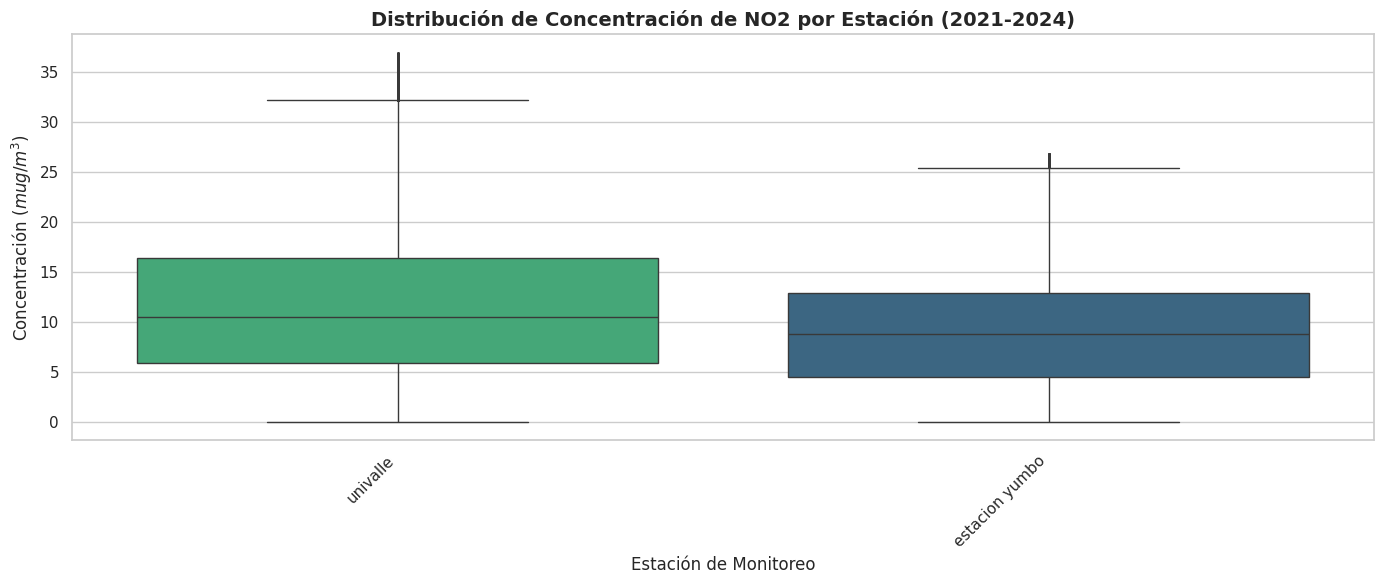

In [16]:
gases = df_dagma["tipo_gas"].unique()

for gas in gases:
    plt.figure(figsize=(14, 6))
    
    df_gas = df_dagma[df_dagma["tipo_gas"] == gas]

    orden_estaciones = (
        df_gas.groupby("nombre_est")["concentracion"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=df_gas,
        x="nombre_est",
        y="concentracion",
        order=orden_estaciones,
        hue="nombre_est",     
        legend=False,
        palette="viridis",
        fliersize=1, 
    )

    plt.title(
        f"Distribución de Concentración de {gas.upper()} por Estación (2021-2024)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Estación de Monitoreo")
    plt.ylabel("Concentración ($mu g/m^3$)")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

AHORA YA TENEMOS DOS ESTACIONES, MELO

# S5P

In [17]:
productos_s5p = {
    "S5P_NO2": "copernicus_s5p_offl_l3_no2",
    "S5P_SO2": "copernicus_s5p_offl_l3_so2",
    "S5P_O3": "copernicus_s5p_offl_l3_o3",
}

In [18]:
for gas, carpeta in productos_s5p.items():
    ruta_zarr = os.path.join(ruta_fuentes, carpeta, "panel.zarr")

In [19]:
df_satelitales = {}


for gas, carpeta in productos_s5p.items():
    ruta_zarr = os.path.join(ruta_fuentes, carpeta, "panel.zarr")

    ds = xr.open_zarr(ruta_zarr, chunks="auto")
    df_satelitales[gas] = ds

    print(f"{gas}")
    print(f"Dimensiones: {dict(ds.sizes)}")

    variables = list(ds.data_vars)
    print(f"Variables: {variables}")

    tiempo_min = ds["time"].min().values
    tiempo_max = ds["time"].max().values
    print(f"Cobertura temporal: Desde {tiempo_min} hasta {tiempo_max}")

S5P_NO2
Dimensiones: {'time': 25592, 'band': 3, 'y': 36, 'x': 36}
Variables: ['data']
Cobertura temporal: Desde 20201231T234906_20210102T163556 hasta 20251231T231651_20260102T152048
S5P_SO2
Dimensiones: {'time': 25829, 'band': 2, 'y': 36, 'x': 36}
Variables: ['data']
Cobertura temporal: Desde 20201231T234906_20210103T005305 hasta 20251231T231651_20260102T211503
S5P_O3
Dimensiones: {'time': 25716, 'band': 2, 'y': 36, 'x': 36}
Variables: ['data']
Cobertura temporal: Desde 20201231T234906_20210102T163551 hasta 20251231T231651_20260102T152044


In [20]:
for gas, ds in df_satelitales.items():
    print(f"\n{gas}")
    nombres_bandas = ds.coords["band"].values

    for b in range(ds.sizes["band"]):
        media_banda = ds["data"].isel(band=b).mean(skipna=True).values
        tag_banda = nombres_bandas[b]
        print(f"  -> Banda {b} ('{tag_banda}') - Media global: {media_banda:.6f}")


S5P_NO2
  -> Banda 0 ('tropospheric_NO2_column_number_density') - Media global: 0.000007
  -> Banda 1 ('NO2_column_number_density') - Media global: 0.000027
  -> Banda 2 ('cloud_fraction') - Media global: 0.189230

S5P_SO2
  -> Banda 0 ('SO2_column_number_density') - Media global: 0.000002
  -> Banda 1 ('cloud_fraction') - Media global: 0.004264

S5P_O3
  -> Banda 0 ('O3_column_number_density') - Media global: 0.104692
  -> Banda 1 ('cloud_fraction') - Media global: 0.548900


In [21]:
for gas in df_satelitales.keys():
    
    df_satelitales[gas] = df_satelitales[gas].sel(time=slice("20210101", "20241231T235959"))
    
    print(f"Temporal de {gas} ahora tenemos estos datos: {df_satelitales[gas].sizes['time']}")

Temporal de S5P_NO2 ahora tenemos estos datos: 20561
Temporal de S5P_SO2 ahora tenemos estos datos: 20660
Temporal de S5P_O3 ahora tenemos estos datos: 20674


In [22]:
for gas, ds in df_satelitales.items():
    print(f"\nFRECUENCIA DE {gas}")
    
    strings_tiempo = ds.coords["time"].values
    strings_limpios = [s.split("_")[0] for s in strings_tiempo]
    tiempos = pd.to_datetime(strings_limpios, format="%Y%m%dT%H%M%S")
    diferencias = tiempos.to_series().diff().dropna()
    
    print(f"  -> Intervalo Mínimo: {diferencias.min()}")
    print(f"  -> Intervalo Máximo: {diferencias.max()}")
    print(f"  -> Intervalo Más Común (Moda): {diferencias.mode()[0]}")
    print(f"  -> Muestra de marcas de tiempo reales: {list(tiempos[:3])}")


FRECUENCIA DE S5P_NO2
  -> Intervalo Mínimo: 0 days 01:41:29
  -> Intervalo Máximo: 1 days 01:22:33
  -> Intervalo Más Común (Moda): 0 days 01:41:30
  -> Muestra de marcas de tiempo reales: [Timestamp('2021-01-01 01:30:36'), Timestamp('2021-01-01 03:12:06'), Timestamp('2021-01-01 04:53:36')]

FRECUENCIA DE S5P_SO2
  -> Intervalo Mínimo: 0 days 01:41:29
  -> Intervalo Máximo: 0 days 11:50:33
  -> Intervalo Más Común (Moda): 0 days 01:41:30
  -> Muestra de marcas de tiempo reales: [Timestamp('2021-01-01 01:30:36'), Timestamp('2021-01-01 03:12:06'), Timestamp('2021-01-01 04:53:36')]

FRECUENCIA DE S5P_O3
  -> Intervalo Mínimo: 0 days 01:41:29
  -> Intervalo Máximo: 0 days 11:50:33
  -> Intervalo Más Común (Moda): 0 days 01:41:30
  -> Muestra de marcas de tiempo reales: [Timestamp('2021-01-01 01:30:36'), Timestamp('2021-01-01 03:12:06'), Timestamp('2021-01-01 04:53:36')]


In [23]:
no2_clouds = df_satelitales["S5P_NO2"]["data"].isel(band=2)
df_satelitales["S5P_NO2"]["data"] = df_satelitales["S5P_NO2"]["data"].where(no2_clouds < 0.7)


so2_clouds = df_satelitales["S5P_SO2"]["data"].isel(band=1)
df_satelitales["S5P_SO2"]["data"] = df_satelitales["S5P_SO2"]["data"].where(so2_clouds < 0.7)

o3_clouds = df_satelitales["S5P_O3"]["data"].isel(band=1)
o3_data_b0 = df_satelitales["S5P_O3"]["data"].isel(band=0)
df_satelitales["S5P_O3"]["data"] = df_satelitales["S5P_O3"]["data"].where((o3_clouds < 0.7) & (o3_data_b0 > 0.0))

print("Filtros re-aplicados con umbral del 70%.")

Filtros re-aplicados con umbral del 70%.


In [24]:
for gas, ds in df_satelitales.items():
    print(f"\n{gas}")
    total_orbitas = ds.sizes["time"]
    serie_promedio = ds["data"].isel(band=0).mean(dim=["x", "y"], skipna=True)
    
    df_limpio = serie_promedio.to_dataframe(name="valor").dropna()
    validos = len(df_limpio)
    
    pct_eliminado = ((total_orbitas - validos) / total_orbitas) * 100
    
    print(f"  -> Órbitas totales analizadas: {total_orbitas}")
    print(f"  -> Órbitas con datos limpios detectados: {validos}")
    print(f"  -> Porcentaje de opacidad por nubes: {pct_eliminado:.2f}%")
    
    print("  -> Perfil estadístico de la distribución limpia:")
    print(df_limpio["valor"].describe().loc[['mean', 'std', 'min', '50%', 'max']].to_string())
    print("-" * 50)


S5P_NO2
  -> Órbitas totales analizadas: 20561
  -> Órbitas con datos limpios detectados: 2365
  -> Porcentaje de opacidad por nubes: 88.50%
  -> Perfil estadístico de la distribución limpia:
mean    0.000011
std     0.000014
min    -0.000006
50%     0.000000
max     0.000078
--------------------------------------------------

S5P_SO2
  -> Órbitas totales analizadas: 20660
  -> Órbitas con datos limpios detectados: 11440
  -> Porcentaje de opacidad por nubes: 44.63%
  -> Perfil estadístico de la distribución limpia:
mean    0.000004
std     0.000057
min    -0.000990
50%     0.000000
max     0.002509
--------------------------------------------------

S5P_O3
  -> Órbitas totales analizadas: 20674
  -> Órbitas con datos limpios detectados: 1253
  -> Porcentaje de opacidad por nubes: 93.94%
  -> Perfil estadístico de la distribución limpia:
mean    0.116634
std     0.005894
min     0.103226
50%     0.116278
max     0.142491
--------------------------------------------------


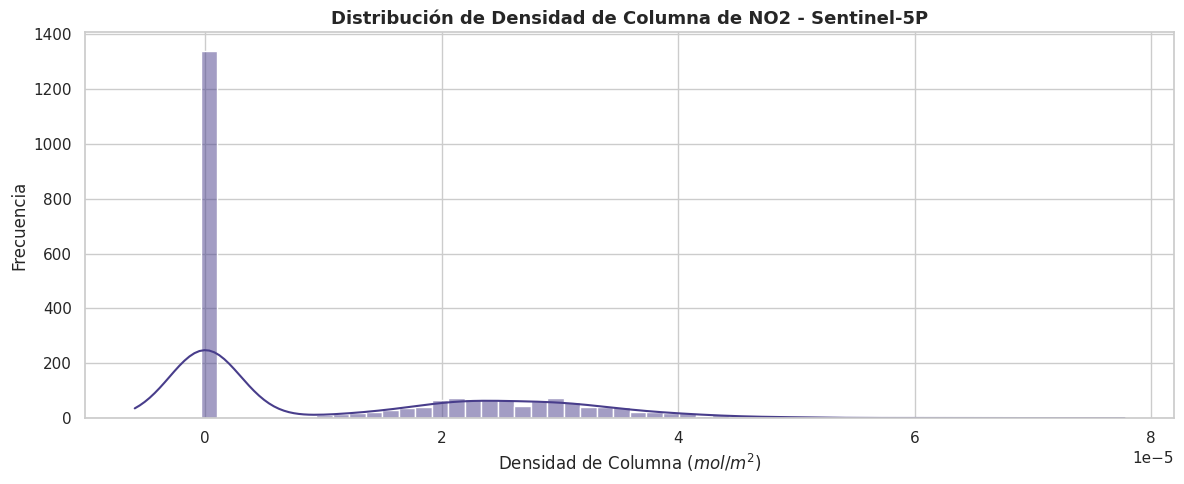

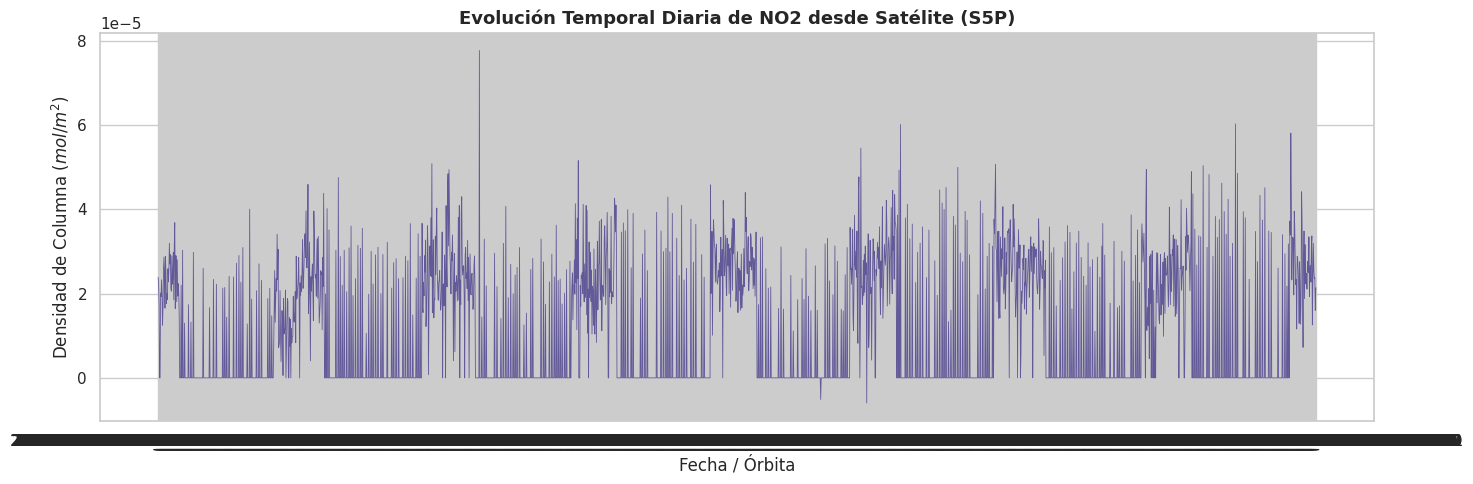

In [25]:
ds_no2_pro = df_satelitales["S5P_NO2"]["data"].isel(band=0).mean(dim=["x", "y"], skipna=True)
df_s5p_no2 = ds_no2_pro.to_dataframe(name="no2_sat").dropna()

plt.figure(figsize=(12, 5))
sns.histplot(data=df_s5p_no2, x="no2_sat", kde=True, color="darkslateblue", bins=60)
plt.title("Distribución de Densidad de Columna de NO2 - Sentinel-5P", fontsize=13, fontweight="bold")
plt.xlabel("Densidad de Columna ($mol/m^2$)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(df_s5p_no2.index, df_s5p_no2["no2_sat"], color="darkslateblue", linewidth=0.6, alpha=0.8)
plt.title("Evolución Temporal Diaria de NO2 desde Satélite (S5P)", fontsize=13, fontweight="bold")
plt.xlabel("Fecha / Órbita")
plt.ylabel("Densidad de Columna ($mol/m^2$)")
plt.tight_layout()
plt.show()

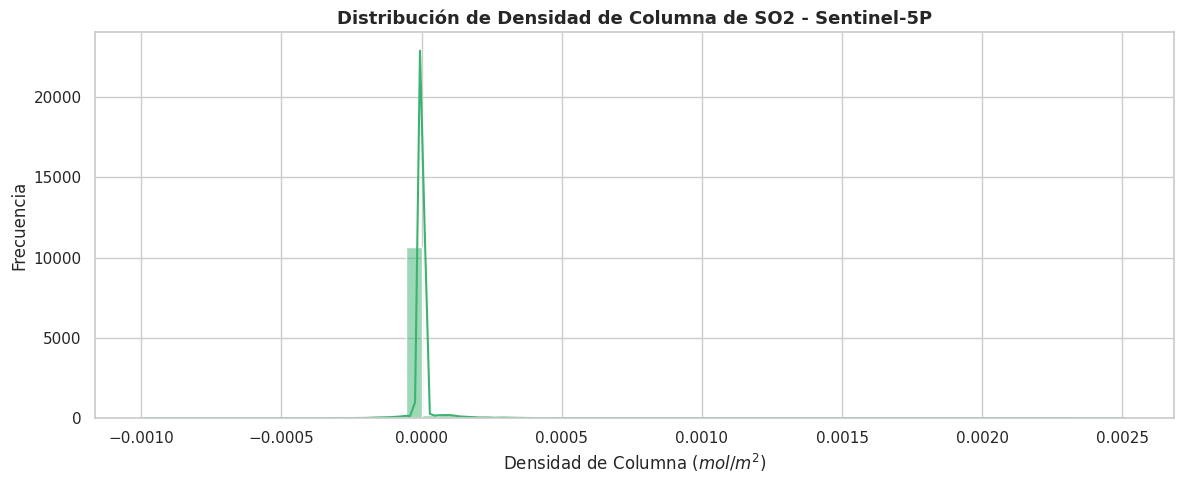

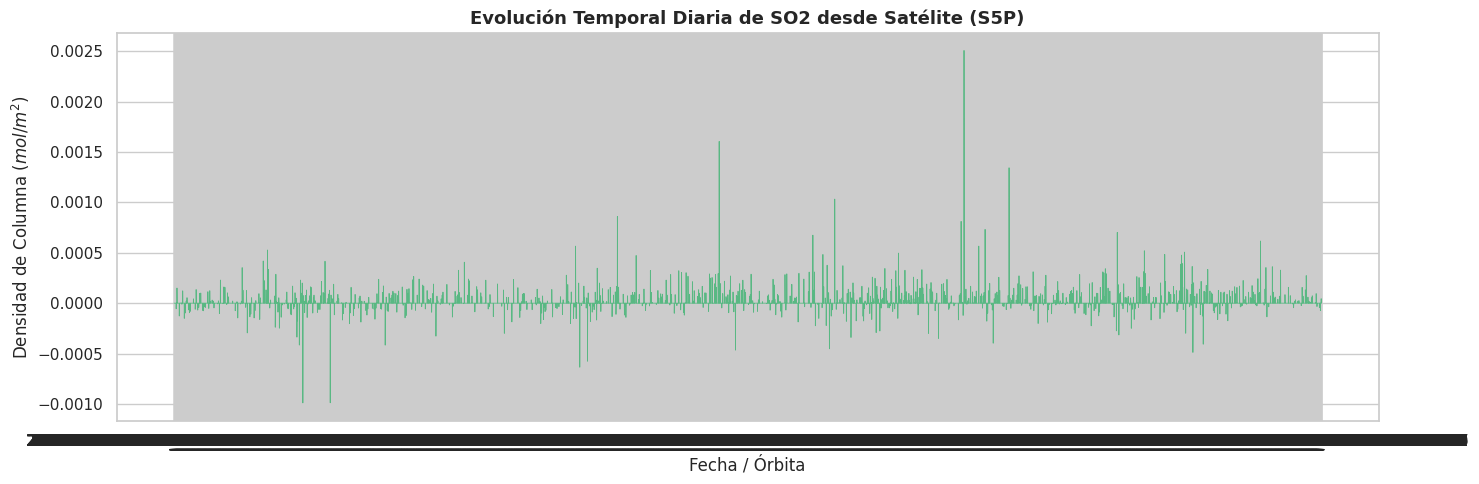

In [26]:
ds_so2_pro = df_satelitales["S5P_SO2"]["data"].isel(band=0).mean(dim=["x", "y"], skipna=True)
df_s5p_so2 = ds_so2_pro.to_dataframe(name="so2_sat").dropna()

plt.figure(figsize=(12, 5))
sns.histplot(data=df_s5p_so2, x="so2_sat", kde=True, color="mediumseagreen", bins=60)
plt.title("Distribución de Densidad de Columna de SO2 - Sentinel-5P", fontsize=13, fontweight="bold")
plt.xlabel("Densidad de Columna ($mol/m^2$)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(df_s5p_so2.index, df_s5p_so2["so2_sat"], color="mediumseagreen", linewidth=0.6, alpha=0.8)
plt.title("Evolución Temporal Diaria de SO2 desde Satélite (S5P)", fontsize=13, fontweight="bold")
plt.xlabel("Fecha / Órbita")
plt.ylabel("Densidad de Columna ($mol/m^2$)")
plt.tight_layout()
plt.show()

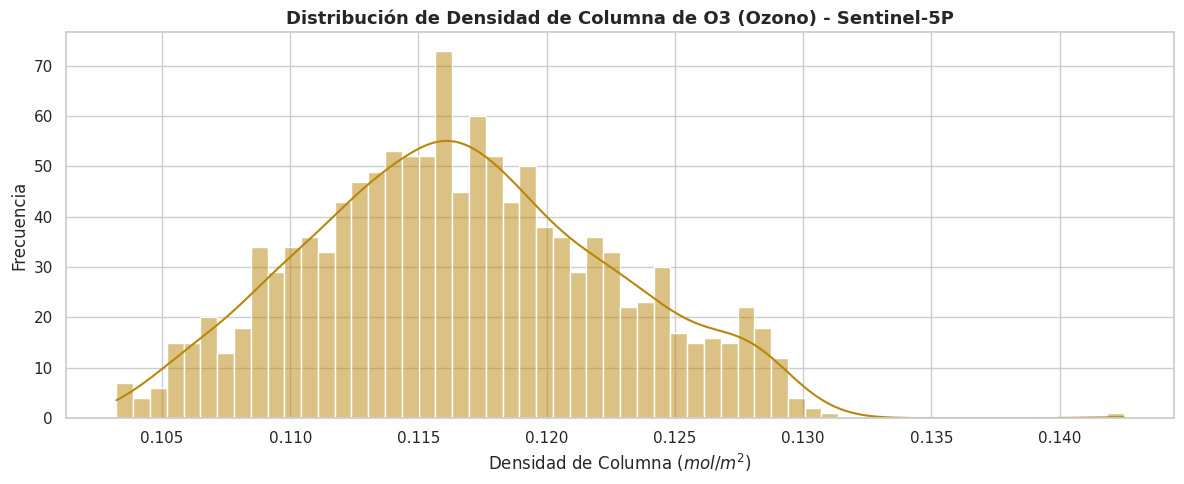

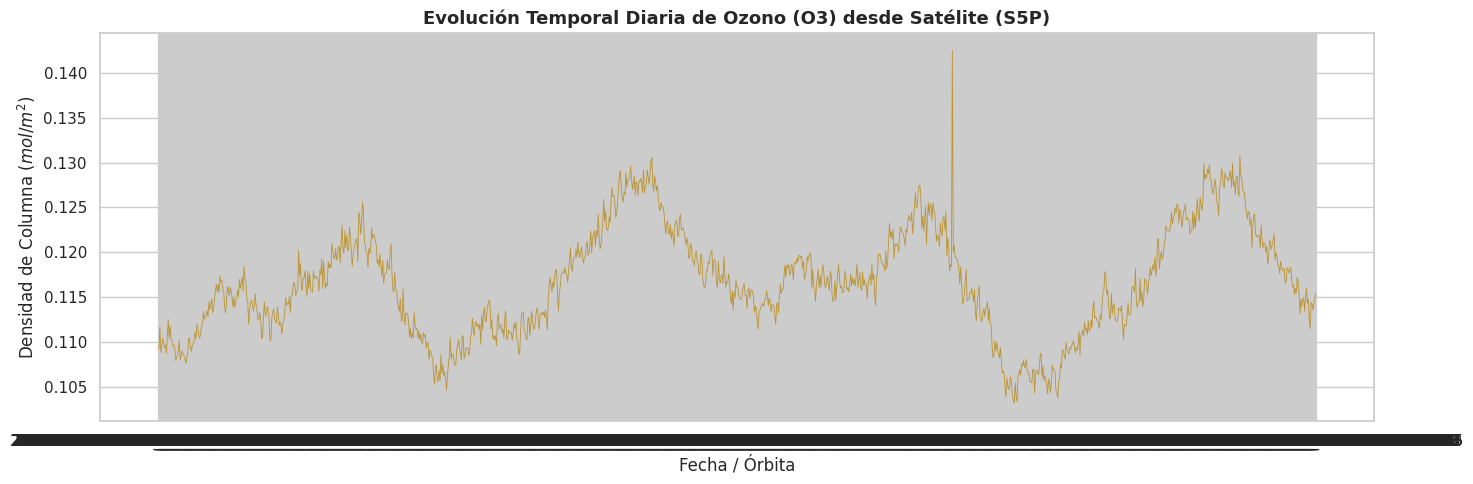

In [27]:
ds_o3_pro = df_satelitales["S5P_O3"]["data"].isel(band=0).mean(dim=["x", "y"], skipna=True)
df_s5p_o3 = ds_o3_pro.to_dataframe(name="o3_sat").dropna()

plt.figure(figsize=(12, 5))
sns.histplot(data=df_s5p_o3, x="o3_sat", kde=True, color="darkgoldenrod", bins=60)
plt.title("Distribución de Densidad de Columna de O3 (Ozono) - Sentinel-5P", fontsize=13, fontweight="bold")
plt.xlabel("Densidad de Columna ($mol/m^2$)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(df_s5p_o3.index, df_s5p_o3["o3_sat"], color="darkgoldenrod", linewidth=0.6, alpha=0.8)
plt.title("Evolución Temporal Diaria de Ozono (O3) desde Satélite (S5P)", fontsize=13, fontweight="bold")
plt.xlabel("Fecha / Órbita")
plt.ylabel("Densidad de Columna ($mol/m^2$)")
plt.tight_layout()
plt.show()

# MODIS

In [28]:
ruta_zarr_modis = os.path.join(ruta_modis, "panel.zarr")
ds_modis = xr.open_zarr(ruta_zarr_modis, chunks="auto")

In [30]:
ruta_zarr_modis = os.path.join(ruta_modis, "panel.zarr")
ds_modis = xr.open_zarr(ruta_zarr_modis, chunks="auto")

print(f"Dimensiones reales en disco: {dict(ds_modis.sizes)}")

Dimensiones reales en disco: {'time': 1826, 'band': 4, 'y': 43, 'x': 43}


In [31]:
muestras_tiempo = ds_modis.coords["time"].values[:5]
print(f"Formato de los strings en 'time': {list(muestras_tiempo)}")
print("-" * 60)

nombres_bandas_modis = ds_modis.coords["band"].values

for b in range(ds_modis.sizes["band"]):
    capa = ds_modis["data"].isel(band=b)
    media = capa.mean(skipna=True).values
    minimo = capa.min(skipna=True).values
    maximo = capa.max(skipna=True).values
    
    tag_banda = nombres_bandas_modis[b]
    print(f"### Banda {b} ('{tag_banda}') ###")
    print(f"  -> Min:  {minimo}")
    print(f"  -> Mean: {media}")
    print(f"  -> Max:  {maximo}")
    print("." * 40)

Formato de los strings en 'time': [np.str_('A2021001'), np.str_('A2021002'), np.str_('A2021003'), np.str_('A2021004'), np.str_('A2021005')]
------------------------------------------------------------
### Banda 0 ('Optical_Depth_047') ###
  -> Min:  0.0
  -> Mean: 0.28944912552833557
  -> Max:  3.4110000133514404
........................................
### Banda 1 ('Optical_Depth_055') ###
  -> Min:  0.0
  -> Mean: 0.20941947400569916
  -> Max:  2.6500000953674316
........................................
### Banda 2 ('Column_WV') ###
  -> Min:  0.054999999701976776
  -> Mean: 1.8742787837982178
  -> Max:  6.210000038146973
........................................
### Banda 3 ('AOD_QA') ###
  -> Min:  0.0
  -> Mean: 940.9459838867188
  -> Max:  11014.0
........................................


In [32]:
ds_modis = ds_modis.sel(time=slice("A2021001", "A2024366"))

print(f"Dimensiones de MODIS después del corte temporal: {dict(ds_modis.sizes)}")
print(f"Primer día en el dataset: {ds_modis.coords['time'].values[0]}")
print(f"Último día en el dataset: {ds_modis.coords['time'].values[-1]}")

Dimensiones de MODIS después del corte temporal: {'time': 1461, 'band': 4, 'y': 43, 'x': 43}
Primer día en el dataset: A2021001
Último día en el dataset: A2024366


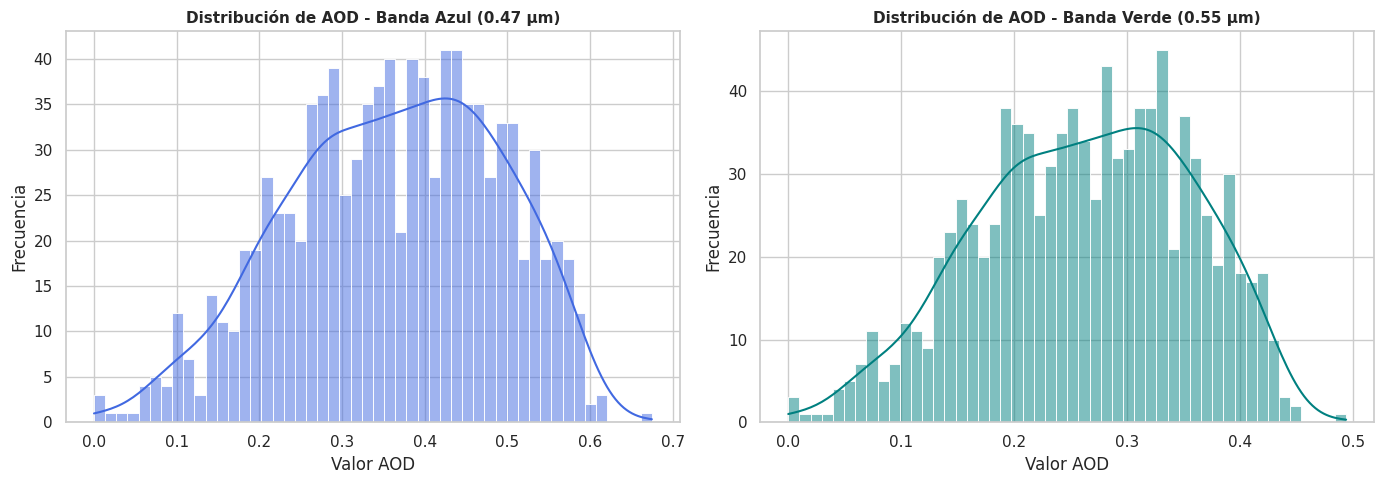

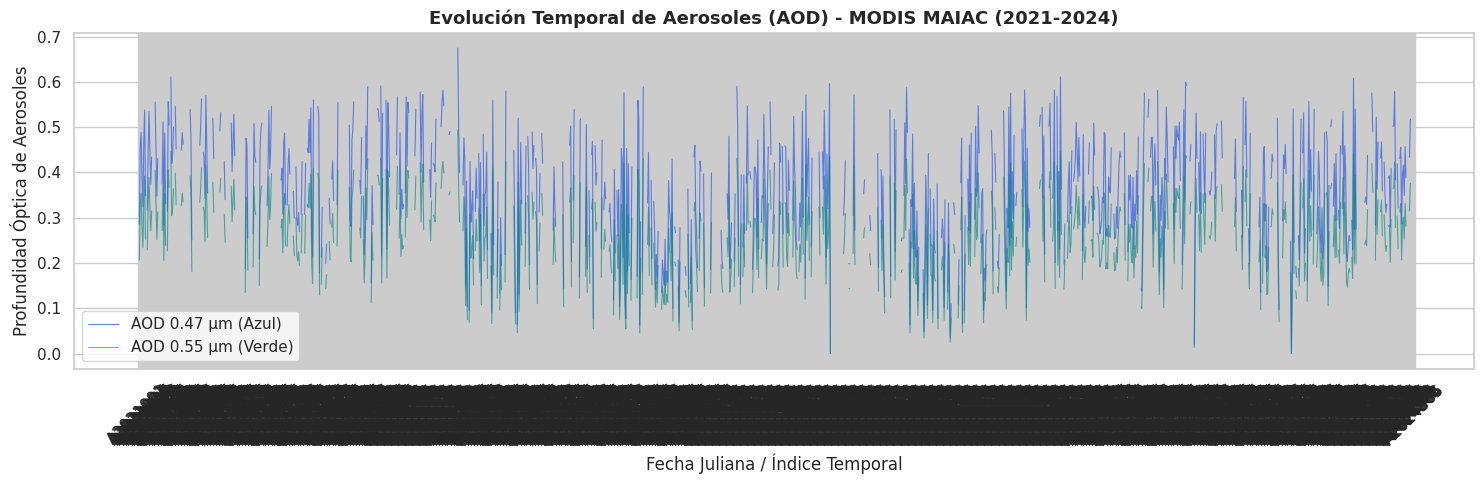

In [34]:
df_modis_047 = ds_modis["data"].isel(band=0).mean(dim=["x", "y"], skipna=True).drop_vars("band").to_dataframe(name="aod_047")
df_modis_055 = ds_modis["data"].isel(band=1).mean(dim=["x", "y"], skipna=True).drop_vars("band").to_dataframe(name="aod_055")

df_graficos_modis = df_modis_047.join(df_modis_055)

# 2. GRAFICAR HISTOGRAMAS DE DISTRIBUCIÓN
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_graficos_modis, x="aod_047", kde=True, color="royalblue", bins=50)
plt.title("Distribución de AOD - Banda Azul (0.47 μm)", fontsize=11, fontweight="bold")
plt.xlabel("Valor AOD")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
sns.histplot(data=df_graficos_modis, x="aod_055", kde=True, color="teal", bins=50)
plt.title("Distribución de AOD - Banda Verde (0.55 μm)", fontsize=11, fontweight="bold")
plt.xlabel("Valor AOD")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# 3. GRAFICAR EVOLUCIÓN TEMPORAL
plt.figure(figsize=(15, 5))
plt.plot(df_graficos_modis.index, df_graficos_modis["aod_047"], label="AOD 0.47 μm (Azul)", color="royalblue", linewidth=0.8, alpha=0.8)
plt.plot(df_graficos_modis.index, df_graficos_modis["aod_055"], label="AOD 0.55 μm (Verde)", color="teal", linewidth=0.8, alpha=0.6)

plt.title("Evolución Temporal de Aerosoles (AOD) - MODIS MAIAC (2021-2024)", fontsize=13, fontweight="bold")
plt.xlabel("Fecha Juliana / Índice Temporal")
plt.ylabel("Profundidad Óptica de Aerosoles")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
fechas_julianas = ds_modis.coords["time"].values
fechas_datetime = pd.to_datetime([str(f)[1:] for f in fechas_julianas], format="%Y%j")

df_fechas = pd.DataFrame(index=fechas_datetime)
df_fechas['diferencia'] = df_fechas.index.to_series().diff()

print(f"-> Fecha de Inicio Real: {fechas_datetime.min().strftime('%Y-%m-%d')} ({fechas_julianas[0]})")
print(f"-> Fecha de Cierre Real: {fechas_datetime.max().strftime('%Y-%m-%d')} ({fechas_julianas[-1]})")
print(f"-> Total de días en la serie: {len(fechas_datetime)}")
print(f"-> Intervalo Mínimo entre registros: {df_fechas['diferencia'].min()}")
print(f"-> Intervalo Máximo entre registros: {df_fechas['diferencia'].max()}")
print(f"-> Intervalo Más Común (Moda): {df_fechas['diferencia'].mode()[0]}")

rango_teorico_completo = pd.date_range(start=fechas_datetime.min(), end=fechas_datetime.max(), freq='D')
dias_faltantes = len(rango_teorico_completo) - len(fechas_datetime)
print(f"-> Días faltantes en la secuencia (huecos): {dias_faltantes}")

-> Fecha de Inicio Real: 2021-01-01 (A2021001)
-> Fecha de Cierre Real: 2024-12-31 (A2024366)
-> Total de días en la serie: 1461
-> Intervalo Mínimo entre registros: 1 days 00:00:00
-> Intervalo Máximo entre registros: 1 days 00:00:00
-> Intervalo Más Común (Moda): 1 days 00:00:00
-> Días faltantes en la secuencia (huecos): 0


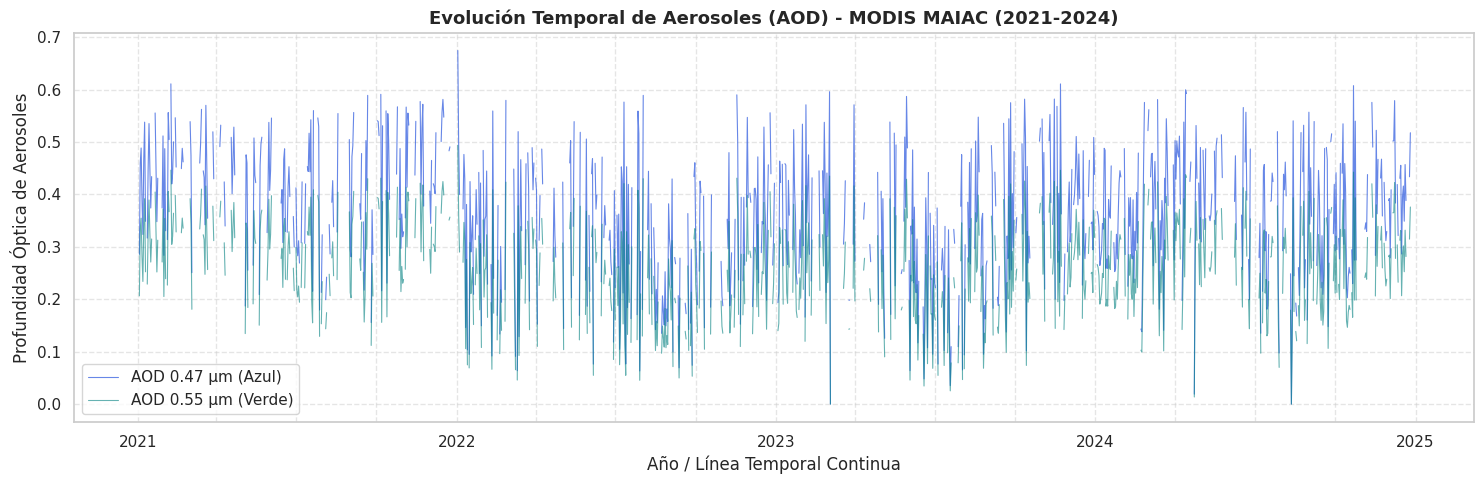

In [39]:
fechas_reales = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")

# 2. Graficar la evolución temporal limpia
plt.figure(figsize=(15, 5))
plt.plot(fechas_reales, df_graficos_modis["aod_047"], label="AOD 0.47 μm (Azul)", color="royalblue", linewidth=0.8, alpha=0.8)
plt.plot(fechas_reales, df_graficos_modis["aod_055"], label="AOD 0.55 μm (Verde)", color="teal", linewidth=0.8, alpha=0.6)

# Configurar el formateador automático del eje X para que muestre los años limpios
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10])) # Marcas sutiles por trimestres

plt.title("Evolución Temporal de Aerosoles (AOD) - MODIS MAIAC (2021-2024)", fontsize=13, fontweight="bold")
plt.xlabel("Año / Línea Temporal Continua")
plt.ylabel("Profundidad Óptica de Aerosoles")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ERA5

In [40]:
ruta_zarr_era5 = os.path.join(ruta_fuentes, "ecmwf_era5_hourly", "panel.zarr")

ds_era5 = xr.open_zarr(ruta_zarr_era5, chunks="auto")

print(f"Dimensiones reales en disco de ERA5: {dict(ds_era5.sizes)}")

if "band" in ds_era5.coords:
    print(f"-> Bandas detectadas en la coordenada 'band': {list(ds_era5.coords['band'].values)}")
else:
    print("-> Variables directas en el Dataset:", list(ds_era5.data_vars))

muestras_tiempo_era5 = ds_era5.coords["time"].values[:5]
print(f"-> Formato de los registros en 'time': {list(muestras_tiempo_era5)}")

Dimensiones reales en disco de ERA5: {'time': 43824, 'band': 8, 'y': 2, 'x': 2}
-> Bandas detectadas en la coordenada 'band': [np.str_('temperature_2m'), np.str_('dewpoint_temperature_2m'), np.str_('u_component_of_wind_10m'), np.str_('v_component_of_wind_10m'), np.str_('boundary_layer_height'), np.str_('relative_humidity_850hPa'), np.str_('surface_pressure'), np.str_('total_precipitation')]
-> Formato de los registros en 'time': [np.str_('20210101T00'), np.str_('20210101T01'), np.str_('20210101T02'), np.str_('20210101T03'), np.str_('20210101T04')]


In [42]:
tiempos_era5_str = ds_era5.coords["time"].values
tiempos_era5_datetime = pd.to_datetime(tiempos_era5_str, format="%Y%m%dT%H")

ds_era5 = ds_era5.assign_coords(time=tiempos_era5_datetime)

ds_era5 = ds_era5.sel(time=slice("2021-01-01", "2024-12-31T23:59:59"))

print(f"Dimensiones de ERA5 tras el filtro temporal: {dict(ds_era5.sizes)}")

diferencias_era5 = pd.Series(ds_era5.coords["time"].values).diff().dropna()

print("\nANALISIS DE FRECUENCIA TEMPORAL (ERA5):")
print(f"  -> Intervalo Mínimo: {diferencias_era5.min()}")
print(f"  -> Intervalo Máximo: {diferencias_era5.max()}")
print(f"  -> Intervalo Más Común (Moda): {diferencias_era5.mode()[0]}")
print(f"  -> Cantidad de registros: {len(ds_era5.coords['time'])} horas")

Dimensiones de ERA5 tras el filtro temporal: {'time': 35064, 'band': 8, 'y': 2, 'x': 2}

ANALISIS DE FRECUENCIA TEMPORAL (ERA5):
  -> Intervalo Mínimo: 0 days 01:00:00
  -> Intervalo Máximo: 0 days 01:00:00
  -> Intervalo Más Común (Moda): 0 days 01:00:00
  -> Cantidad de registros: 35064 horas



Primeros registros de df_era5:
                     temperatura_c  capa_limite_m  humedad_relativa  \
2021-01-01 00:00:00      20.854004      86.947754         90.949142   
2021-01-01 01:00:00      20.641296     100.377625         90.949142   
2021-01-01 02:00:00      20.150024      69.772095         90.949142   
2021-01-01 03:00:00      20.107544      81.105530         90.949142   
2021-01-01 04:00:00      19.882263      71.284729         90.949142   

                     precipitacion_mm  
2021-01-01 00:00:00          0.094067  
2021-01-01 01:00:00          0.221069  
2021-01-01 02:00:00          0.059663  
2021-01-01 03:00:00          0.032324  
2021-01-01 04:00:00          0.042873  


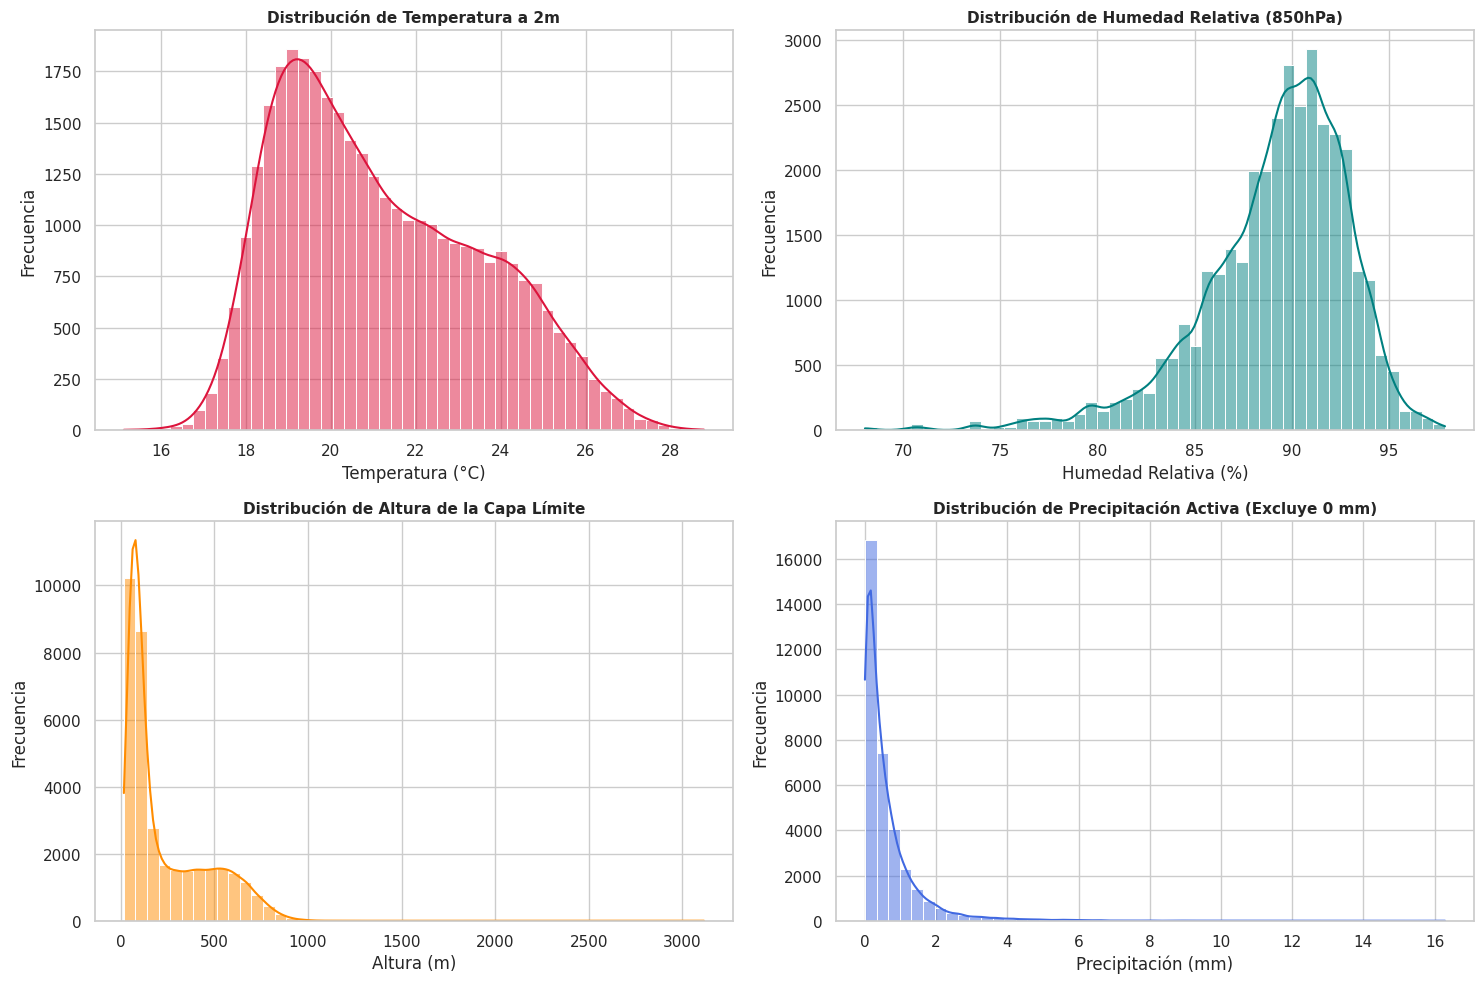

In [43]:
df_era5 = pd.DataFrame({
    "temperatura_c": ds_era5["data"].isel(band=0).mean(dim=["x", "y"], skipna=True).values - 273.15,
    "capa_limite_m": ds_era5["data"].isel(band=4).mean(dim=["x", "y"], skipna=True).values,
    "humedad_relativa": ds_era5["data"].isel(band=5).mean(dim=["x", "y"], skipna=True).values,
    "precipitacion_mm": ds_era5["data"].isel(band=7).mean(dim=["x", "y"], skipna=True).values * 1000
}, index=ds_era5.coords["time"].values)

print("\nPrimeros registros de df_era5:")
print(df_era5.head())

# 2. Graficar distribuciones usando df_era5
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.set_theme(style="whitegrid")

sns.histplot(data=df_era5, x="temperatura_c", kde=True, color="crimson", bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de Temperatura a 2m", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Temperatura (°C)")
axes[0, 0].set_ylabel("Frecuencia")

sns.histplot(data=df_era5, x="humedad_relativa", kde=True, color="teal", bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Distribución de Humedad Relativa (850hPa)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Humedad Relativa (%)")
axes[0, 1].set_ylabel("Frecuencia")

sns.histplot(data=df_era5, x="capa_limite_m", kde=True, color="darkorange", bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Distribución de Altura de la Capa Límite", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Altura (m)")
axes[1, 0].set_ylabel("Frecuencia")

sns.histplot(data=df_era5[df_era5["precipitacion_mm"] > 0], x="precipitacion_mm", kde=True, color="royalblue", bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Distribución de Precipitación Activa (Excluye 0 mm)", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Precipitación (mm)")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

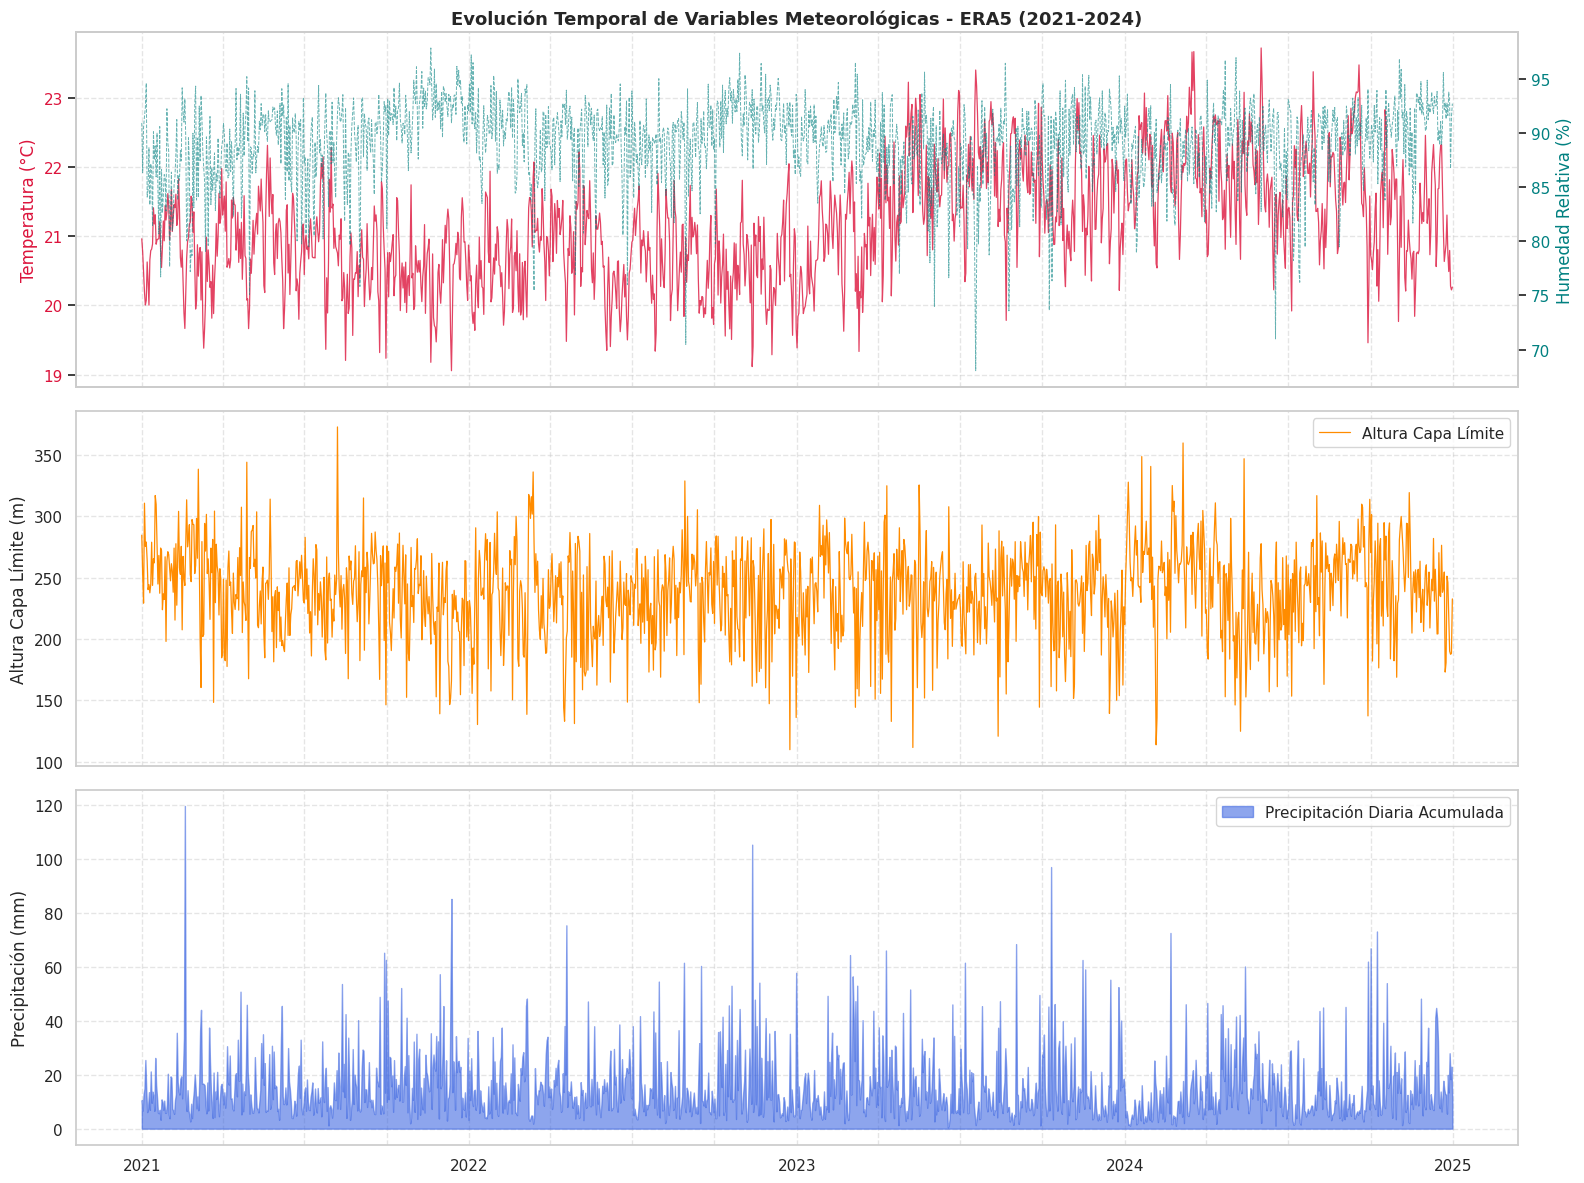

In [44]:
df_era5 = df_era5.resample("D").agg({
    "temperatura_c": "mean",
    "capa_limite_m": "mean",
    "humedad_relativa": "mean",
    "precipitacion_mm": "sum"
})

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)


axes[0].plot(df_era5.index, df_era5["temperatura_c"], label="Temperatura Promedio (°C)", color="crimson", linewidth=0.9, alpha=0.8)
axes[0].set_ylabel("Temperatura (°C)", color="crimson")
axes[0].tick_params(axis='y', labelcolor="crimson")
axes[0].set_title("Evolución Temporal de Variables Meteorológicas - ERA5 (2021-2024)", fontsize=13, fontweight="bold")

ax0_twin = axes[0].twinx()
ax0_twin.plot(df_era5.index, df_era5["humedad_relativa"], label="Humedad Relativa (%)", color="teal", linewidth=0.7, alpha=0.6, linestyle="--")
ax0_twin.set_ylabel("Humedad Relativa (%)", color="teal")
ax0_twin.tick_params(axis='y', labelcolor="teal")
ax0_twin.grid(False)

axes[1].plot(df_era5.index, df_era5["capa_limite_m"], label="Altura Capa Límite", color="darkorange", linewidth=0.9)
axes[1].set_ylabel("Altura Capa Límite (m)")
axes[1].legend(loc="upper right")

axes[2].fill_between(df_era5.index, df_era5["precipitacion_mm"], color="royalblue", alpha=0.6, label="Precipitación Diaria Acumulada")
axes[2].set_ylabel("Precipitación (mm)")
axes[2].legend(loc="upper right")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.xlabel("Año / Línea Temporal Continua")
plt.tight_layout()
plt.show()

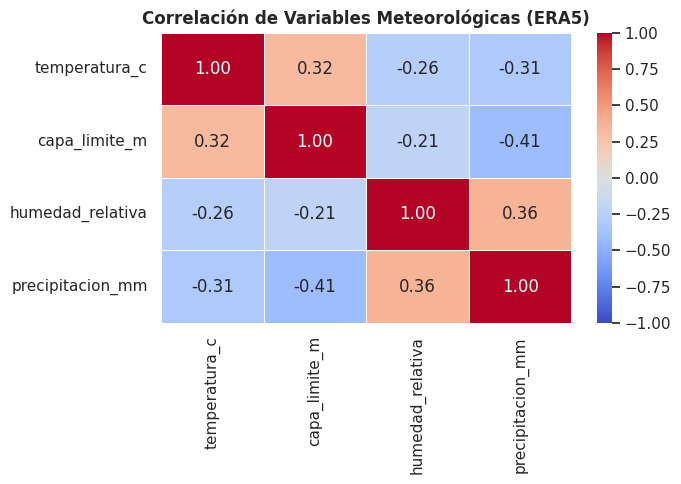

In [48]:
plt.figure(figsize=(7, 5))
sns.heatmap(df_era5.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlación de Variables Meteorológicas (ERA5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# SENTINEL 2

In [54]:
ruta_zarr_s2 = os.path.join(ruta_fuentes, "copernicus_s2_sr_harmonized", "panel.zarr")
ds_s2 = xr.open_zarr(ruta_zarr_s2, chunks="auto")

print("=== ESTRUCTURA DE SENTINEL-2 ===")
print(f"Dimensiones reales: {dict(ds_s2.sizes)}")
print(f"Variables de datos: {list(ds_s2.data_vars)}")

if "band" in ds_s2.coords:
    print(f"Bandas detectadas: {list(ds_s2.coords['band'].values)}")
else:
    print("Coordenadas disponibles:", list(ds_s2.coords))

muestras_tiempo_s2 = ds_s2.coords["time"].values
print(f"\nNúmero de registros temporales: {len(muestras_tiempo_s2)}")
print(f"Primeras 5 marcas de tiempo: {list(muestras_tiempo_s2[:5])}")
print(f"Últimas 5 marcas de tiempo: {list(muestras_tiempo_s2[-5:])}")

=== ESTRUCTURA DE SENTINEL-2 ===
Dimensiones reales: {'time': 1552, 'band': 13, 'y': 3897, 'x': 3897}
Variables de datos: ['data']
Bandas detectadas: [np.str_('B1'), np.str_('B2'), np.str_('B3'), np.str_('B4'), np.str_('B5'), np.str_('B6'), np.str_('B7'), np.str_('B8'), np.str_('B8A'), np.str_('B9'), np.str_('B11'), np.str_('B12'), np.str_('SCL')]

Número de registros temporales: 1552
Primeras 5 marcas de tiempo: [np.str_('20210103T152641_20210103T153117_T18NUJ'), np.str_('20210103T152641_20210103T153117_T18NUK'), np.str_('20210106T153621_20210106T154053_T18NUJ'), np.str_('20210106T153621_20210106T154053_T18NUK'), np.str_('20210108T152639_20210108T153127_T18NUJ')]
Últimas 5 marcas de tiempo: [np.str_('20251228T152701_20251228T152837_T18NUK'), np.str_('20251230T152941_20251230T152942_T18NUJ'), np.str_('20251230T152941_20251230T152942_T18NUK'), np.str_('20251231T153631_20251231T153632_T18NUJ'), np.str_('20251231T153631_20251231T153632_T18NUK')]


In [61]:
elementos_tiles = os.listdir(ruta_tiles)
print(elementos_tiles)

['tiles_train.npz', 'tiles_meta.parquet', 'scl_por_escena.csv']


In [62]:
df_meta = pd.read_parquet(os.path.join(ruta_tiles, "tiles_meta.parquet"))
print("=== METADATOS DE LOS TILES (tiles_meta.parquet) ===")
print(f"Dimensiones: {df_meta.shape} (Filas, Columnas)")
print(f"Columnas disponibles: {df_meta.columns.tolist()}")
print("\nMuestra de los primeros registros:")
print(df_meta.head(3))
print("-" * 60)

=== METADATOS DE LOS TILES (tiles_meta.parquet) ===
Dimensiones: (5000, 22) (Filas, Columnas)
Columnas disponibles: ['clase', 'time_s2', 'lat', 'lon', 'ndvi', 'ndbi', 'scl_pct', 'no2', 'so2', 'o3', 'texto', 'era5_T2m', 'era5_Td2m', 'era5_u10', 'era5_v10', 'era5_BLH', 'era5_RH850', 'era5_psurf', 'era5_precip', 'modis_AOD_047', 'modis_AOD_055', 'modis_WV']

Muestra de los primeros registros:
                    clase                                 time_s2       lat  \
0  contaminacion_alta_NO2  20230829T153619_20230829T153712_T18NUJ  3.512862   
1  contaminacion_alta_NO2  20240220T153621_20240220T153623_T18NUJ  3.556161   
2  contaminacion_alta_NO2  20210903T153621_20210903T154145_T18NUJ  3.375150   

         lon      ndvi      ndbi   scl_pct       no2  so2  o3  ...  \
0 -76.313051  0.601409 -0.100395  0.944092  0.000078  NaN NaN  ...   
1 -76.490109  0.425136 -0.048721  1.000000  0.000080  NaN NaN  ...   
2 -76.571766  0.706977 -0.193641  1.000000  0.000068  NaN NaN  ...   

    era5_

In [63]:
with np.load(os.path.join(ruta_tiles, "tiles_train.npz")) as data_npz:
    claves = list(data_npz.keys())
    print(f"Claves detectadas dentro del archivo .npz: {claves}")
    for clave in claves:
        array_data = data_npz[clave]
        print(f"  -> Arreglo '{clave}':")
        print(f"     * Forma (Shape): {array_data.shape}")
        print(f"     * Tipo de Dato (Dtype): {array_data.dtype}")

Claves detectadas dentro del archivo .npz: ['data', 'bands']
  -> Arreglo 'data':
     * Forma (Shape): (5000, 13, 64, 64)
     * Tipo de Dato (Dtype): float32
  -> Arreglo 'bands':
     * Forma (Shape): (13,)
     * Tipo de Dato (Dtype): <U3


In [64]:
df_scl = pd.read_csv(os.path.join(ruta_tiles, "scl_por_escena.csv"))
print("\n=== CLASIFICACIÓN ESCENA SCL (scl_por_escena.csv) ===")
print(f"Dimensiones: {df_scl.shape} (Filas, Columnas)")
print("\nMuestra de los primeros registros:")
print(df_scl.head(3))


=== CLASIFICACIÓN ESCENA SCL (scl_por_escena.csv) ===
Dimensiones: (1552, 3) (Filas, Columnas)

Muestra de los primeros registros:
   time_idx                                 time_s2   scl_pct
0         0  20210103T152641_20210103T153117_T18NUJ  0.000000
1         1  20210103T152641_20210103T153117_T18NUK  0.000000
2         2  20210106T153621_20210106T154053_T18NUJ  0.102335


clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
vegetacion_densa          1000
suelo_urbano              1000
Name: count, dtype: int64


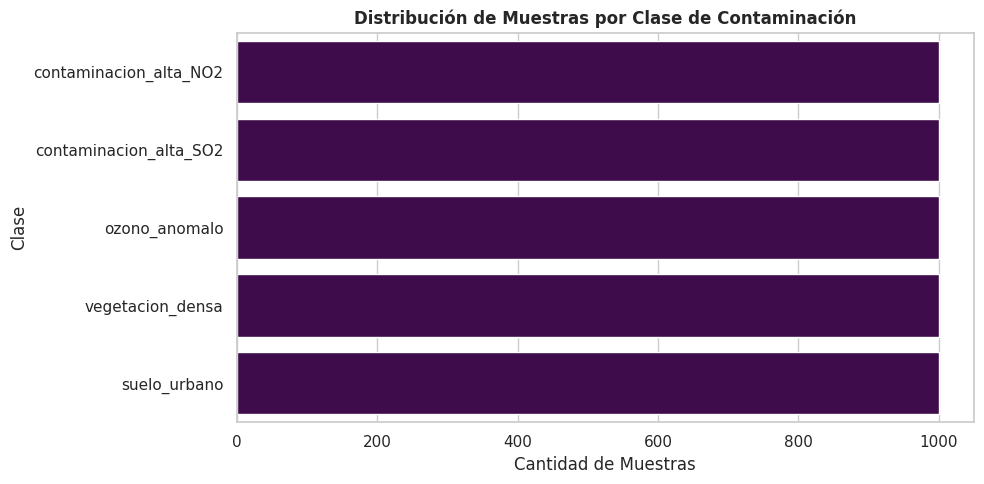

In [68]:
conteo_clases = df_meta["clase"].value_counts()
print(conteo_clases)

# Graficar balance de clases
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_clases.values, y=conteo_clases.index, palette="viridis", hue=conteo_clases.values, legend=False)
plt.title("Distribución de Muestras por Clase de Contaminación", fontsize=12, fontweight="bold")
plt.xlabel("Cantidad de Muestras")
plt.ylabel("Clase")
plt.tight_layout()
plt.show()


In [65]:
nulos_pct = (df_meta.isnull().sum() / len(df_meta)) * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=False)

if len(nulos_pct) > 0:
    print(nulos_pct.map("{:.2f}%".format))


modis_AOD_055    84.66%
modis_AOD_047    84.66%
so2              80.00%
no2              80.00%
o3               80.00%
modis_WV          2.06%
dtype: object


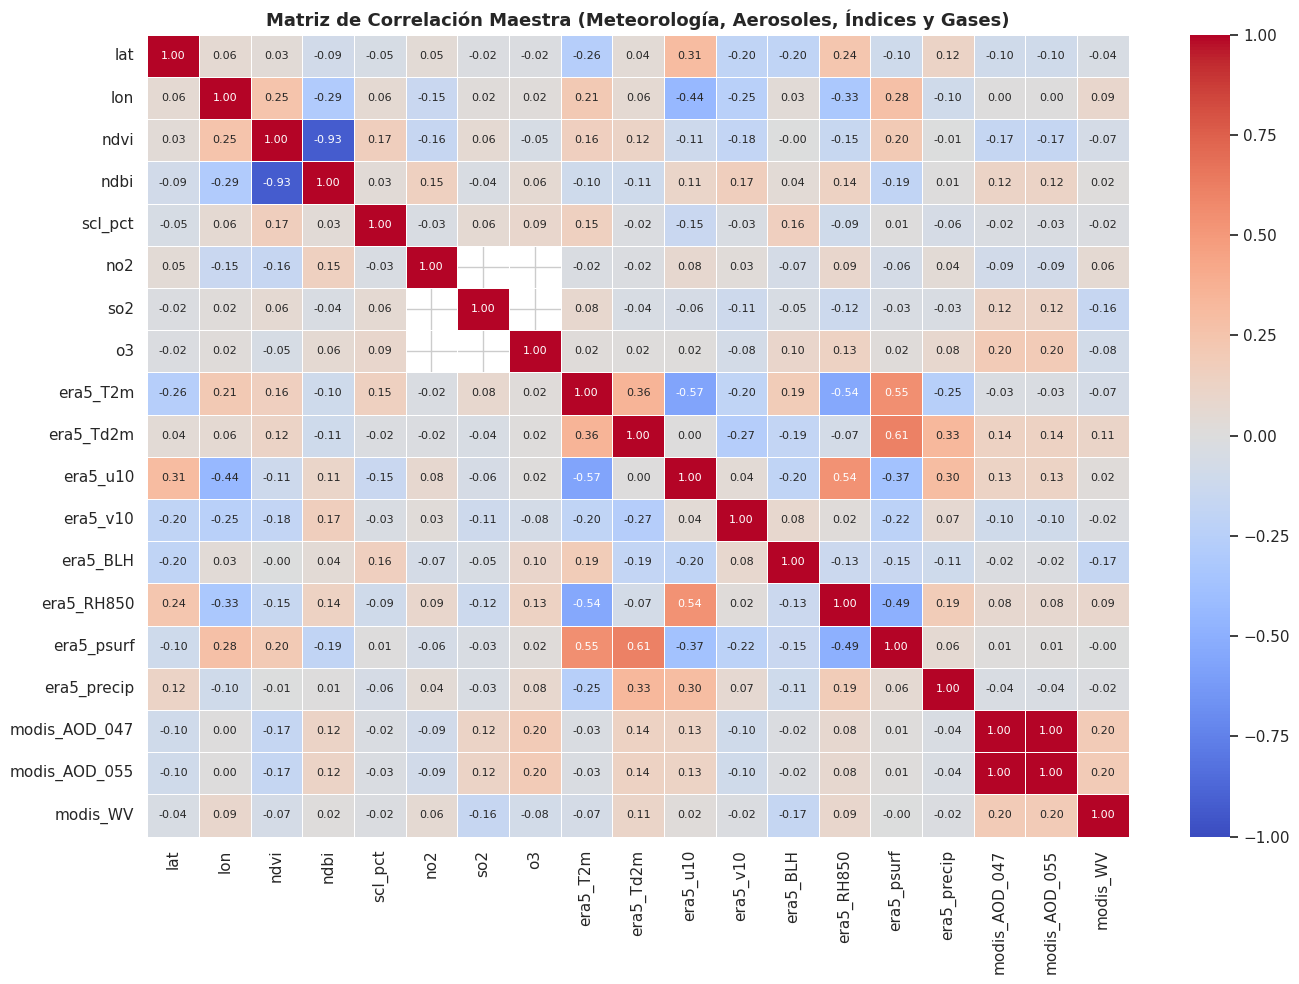

In [69]:
columnas_numericas = df_meta.select_dtypes(include=["float64", "float32", "int64"]).columns

# Graficar la correlación maestra de todo el ecosistema alineado
plt.figure(figsize=(14, 10))
sns.heatmap(df_meta[columnas_numericas].corr(method="pearson"), 
            annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Matriz de Correlación Maestra (Meteorología, Aerosoles, Índices y Gases)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# MAPA CALI CON ESTACIONES

In [75]:
CALI_BBOX = [-76.65, 3.30, -76.30, 3.65]

centro_lat = (CALI_BBOX[1] + CALI_BBOX[3]) / 2
centro_lon = (CALI_BBOX[0] + CALI_BBOX[2]) / 2

mapa_cali = folium.Map(location=[centro_lat, centro_lon], zoom_start=11, tiles="cartodbpositron")

limites_folium = [[CALI_BBOX[1], CALI_BBOX[0]], [CALI_BBOX[3], CALI_BBOX[2]]]
folium.Rectangle(
    bounds=limites_folium,
    color="crimson",
    weight=2,
    fill=True,
    fill_color="crimson",
    fill_opacity=0.08,
    popup="BBOX Cali / Yumbo"
).add_to(mapa_cali)

df_estaciones_unicas = df_dagma.groupby("nombre_est")[["latitud", "longitud", "altitud"]].mean().reset_index()

for _, fila in df_estaciones_unicas.iterrows():
    texto_popup = f"""
    <b>Estación:</b> {str(fila['nombre_est']).title()}<br>
    <b>Altitud Promedio:</b> {fila['altitud']:.1f} msnm<br>
    <b>Coordenadas:</b> {fila['latitud']:.5f}, {fila['longitud']:.5f}
    """
    
    folium.Marker(
        location=[fila["latitud"], fila["longitud"]],
        popup=folium.Popup(texto_popup, max_width=250),
        tooltip=str(fila["nombre_est"]).title(),
        icon=folium.Icon(color="darkblue", icon="info-sign")
    ).add_to(mapa_cali)

# Renderizar el mapa limpio
mapa_cali

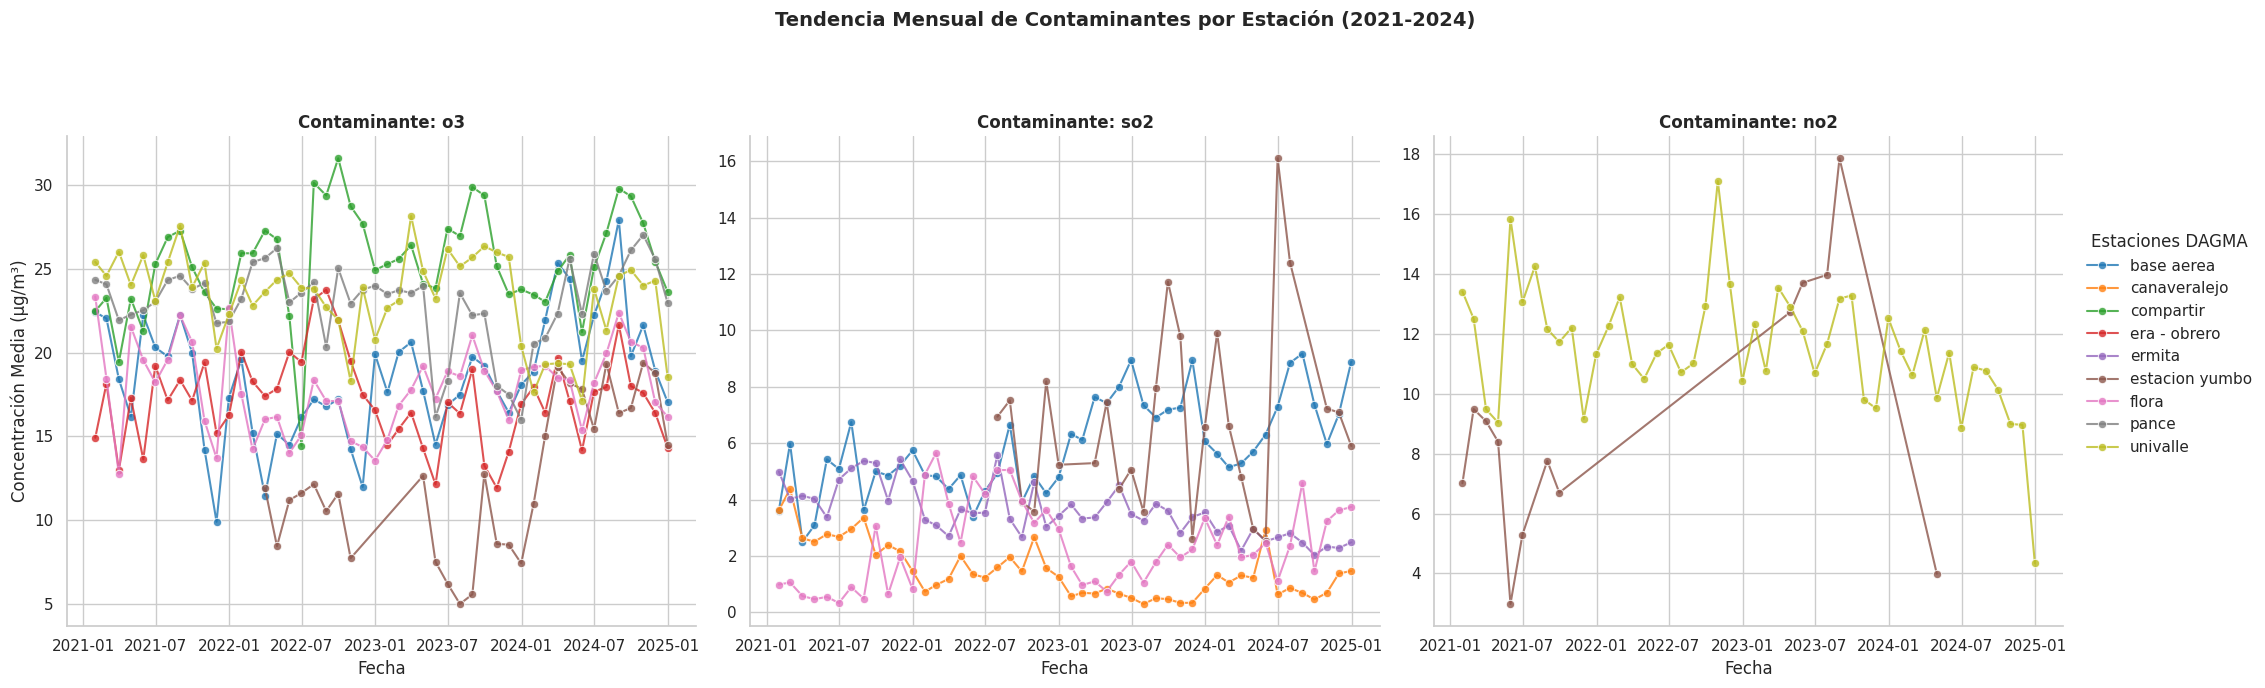

In [82]:
df_estaciones_temporal = df_dagma.groupby([
    pd.Grouper(key="fecha", freq="ME"), "nombre_est", "tipo_gas"
])["concentracion"].mean().reset_index()

g = sns.FacetGrid(df_estaciones_temporal, col="tipo_gas", hue="nombre_est", 
                  col_wrap=3, height=7, aspect=1, sharey=False, palette="tab10")

g.map(sns.lineplot, "fecha", "concentracion", marker="o", linewidth=1.5, alpha=0.8)

g.add_legend(title="Estaciones DAGMA")
g.set_titles("Contaminante: {col_name}", fontweight="bold")
g.set_axis_labels("Fecha", "Concentración Media (μg/m³)")

plt.subplots_adjust(top=0.8)
g.fig.suptitle("Tendencia Mensual de Contaminantes por Estación (2021-2024)", fontsize=14, fontweight="bold")
plt.show()

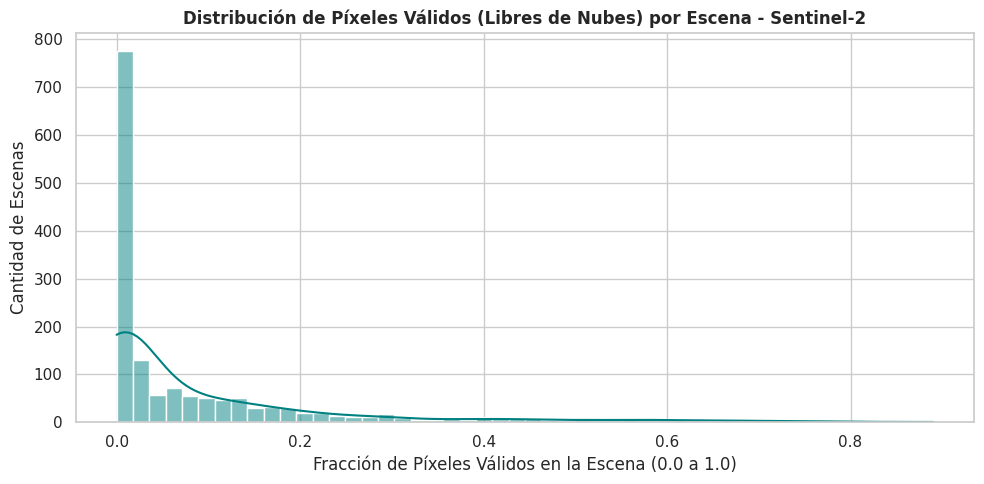

In [83]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df_scl, x="scl_pct", kde=True, color="teal", bins=50)

plt.title("Distribución de Píxeles Válidos (Libres de Nubes) por Escena - Sentinel-2", fontsize=12, fontweight="bold")
plt.xlabel("Fracción de Píxeles Válidos en la Escena (0.0 a 1.0)")
plt.ylabel("Cantidad de Escenas")
plt.tight_layout()
plt.show()

In [85]:
total_escenas = len(df_scl)
# Filtrar escenas que tengan al menos 70% de píxeles válidos (scl_pct >= 0.70)
df_escenas_limpias = df_scl[df_scl["scl_pct"] >= 0.70].copy()
num_limpias = len(df_escenas_limpias)
porcentaje_utilizable = (num_limpias / total_escenas) * 100

print("=== ANÁLISIS DE CALIDAD DE ESCENAS (SCL) ===")
print(f"Total de escenas en el histórico original: {total_escenas}")
print(f"Escenas que cumplen con el filtro (> 70% limpio): {num_limpias}")
print(f"Porcentaje de escenas útiles para el modelo: {porcentaje_utilizable:.2f}%")

print("\nMuestra de las 10 escenas más limpias disponibles:")
print(df_escenas_limpias.sort_values(by="scl_pct", ascending=False).head(10))
print("-" * 70)

# 2. DIAGNÓSTICO DEL SATÉLITE COBERTOR (Análisis de Órbita)
print("\n=== ANÁLISIS DE FRECUENCIA ORBITAL (S2A vs S2B) ===")

# Separar las escenas por Tile para no mezclar las órbitas en el cálculo
df_escenas_limpias["tile"] = df_escenas_limpias["time_s2"].apply(lambda x: x.split("_")[-1] if "_" in str(x) else "Desconocido")
df_tile_nuj = df_escenas_limpias[df_escenas_limpias["tile"] == "T18NUJ"].copy()

# Extraer y limpiar la fecha de adquisición para calcular los días entre capturas
df_tile_nuj["fecha_pura"] = pd.to_datetime(df_tile_nuj["time_s2"].apply(lambda x: x.split("T")[0] if "T" in str(x) else x), format="%Y%m%d")
df_tile_nuj = df_tile_nuj.sort_values(by="fecha_pura")

# Calcular la diferencia en días entre pasos consecutivos sobre el mismo tile
diferencias_dias = df_tile_nuj["fecha_pura"].diff().dt.days.dropna()

if len(diferencias_dias) > 0:
    intervalo_minimo = diferencias_dias.min()
    intervalo_comun = diferencias_dias.mode()[0] if not diferencias_dias.mode().empty else np.nan
    
    print(f"Para el Tile T18NUJ:")
    print(f"  -> Intervalo de paso mínimo detectado: {intervalo_minimo} días")
    print(f"  -> Intervalo de paso más común (Moda): {intervalo_comun} días")
    
    if decimal_comun := intervalo_comun:
        if decimal_comun >= 9:
            print("\nDiagnóstico: El intervalo de ~10 días sugiere que el dataset solo incluye")
            print("datos de un único satélite (muy probablemente solo Sentinel-2A o solo Sentinel-2B).")
        else:
            print("\nDiagnóstico: El intervalo de ~5 días sugiere que ambos satélites")
            print("(Sentinel-2A y Sentinel-2B) están aportando datos a tu BBOX de forma combinada.")
else:
    print("No hay suficientes escenas limpias consecutivas para calcular la frecuencia de órbita.")

=== ANÁLISIS DE CALIDAD DE ESCENAS (SCL) ===
Total de escenas en el histórico original: 1552
Escenas que cumplen con el filtro (> 70% limpio): 17
Porcentaje de escenas útiles para el modelo: 1.10%

Muestra de las 10 escenas más limpias disponibles:
      time_idx                                 time_s2   scl_pct
1041      1041  20240729T153631_20240729T153708_T18NUJ  0.890044
745        745  20230720T153629_20230720T153804_T18NUJ  0.889481
1055      1055  20240818T153631_20240818T153625_T18NUJ  0.872422
163        163  20210720T153619_20210720T154204_T18NUJ  0.809965
777        777  20230829T153619_20230829T153712_T18NUJ  0.795223
95          95  20210501T153619_20210501T153854_T18NUJ  0.790003
1079      1079  20240917T153631_20240917T154016_T18NUJ  0.785334
479        479  20220824T153619_20220824T153619_T18NUJ  0.780641
1063      1063  20240828T153621_20240828T154039_T18NUJ  0.774567
721        721  20230620T153619_20230620T153915_T18NUJ  0.748635
------------------------------------

In [86]:
df_meta["tile_mgrs"] = df_meta["time_s2"].apply(lambda x: x.split("_")[-1] if "_" in str(x) else "Desconocido")


print(df_meta["tile_mgrs"].value_counts())

print("\n=== DISTRIBUCIÓN DE CLASES DE CONTAMINACIÓN POR TILE ===")
print(pd.crosstab(df_meta["tile_mgrs"], df_meta["clase"]))

tile_mgrs
T18NUJ    4993
T18NUK       7
Name: count, dtype: int64

=== DISTRIBUCIÓN DE CLASES DE CONTAMINACIÓN POR TILE ===
clase      contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
tile_mgrs                                                                  
T18NUJ                       1000                    1000            993   
T18NUK                          0                       0              7   

clase      suelo_urbano  vegetacion_densa  
tile_mgrs                                  
T18NUJ             1000              1000  
T18NUK                0                 0  


# COBERTURA DE LOS SATELITES EN EL MAPA DE NOSOTROS

In [87]:
cobertura_tiles = df_meta.groupby("tile_mgrs")[["lat", "lon"]].agg(["min", "max"])
print(cobertura_tiles)

centro_lat = (CALI_BBOX[1] + CALI_BBOX[3]) / 2
centro_lon = (CALI_BBOX[0] + CALI_BBOX[2]) / 2

mapa_cobertura = folium.Map(location=[centro_lat, centro_lon], zoom_start=11, tiles="cartodbpositron")

limites_bbox = [[CALI_BBOX[1], CALI_BBOX[0]], [CALI_BBOX[3], CALI_BBOX[2]]]
folium.Rectangle(
    bounds=limites_bbox,
    color="crimson",
    weight=1.5,
    fill=False,
    popup="BBOX Original Cali / Yumbo"
).add_to(mapa_cobertura)

# 5. Dibujar las Huellas de tus Muestras por Tile (Naranja para T18NUJ, Púrpura para T18NUK)
colores_tiles = {"T18NUJ": "orange", "T18NUK": "purple"}

for tile, fila in cobertura_tiles.iterrows():
    limites_tile = [
        [fila[("lat", "min")], fila[("lon", "min")]],
        [fila[("lat", "max")], fila[("lon", "max")]]
    ]
    
    conteo_muestras = df_meta["tile_mgrs"].value_counts()[tile]
    
    folium.Rectangle(
        bounds=limites_tile,
        color=colores_tiles.get(tile, "gray"),
        weight=2.5,
        fill=True,
        fill_color=colores_tiles.get(tile, "gray"),
        fill_opacity=0.15,
        popup=f"Huella de {tile} ({conteo_muestras} muestras)"
    ).add_to(mapa_cobertura)

df_estaciones_unicas = df_dagma.groupby("nombre_est")[["latitud", "longitud", "altitud"]].mean().reset_index()

for _, fila in df_estaciones_unicas.iterrows():
    texto_popup = f"""
    <b>Estación:</b> {str(fila['nombre_est']).title()}<br>
    <b>Altitud:</b> {fila['altitud']:.1f} msnm<br>
    <b>Coordenadas:</b> {fila['latitud']:.5f}, {fila['longitud']:.5f}
    """
    
    folium.Marker(
        location=[fila["latitud"], fila["longitud"]],
        popup=folium.Popup(texto_popup, max_width=250),
        tooltip=str(fila["nombre_est"]).title(),
        icon=folium.Icon(color="darkblue", icon="info-sign")
    ).add_to(mapa_cobertura)

mapa_cobertura

                lat                  lon           
                min       max        min        max
tile_mgrs                                          
T18NUJ     3.302926  3.618773 -76.645518 -76.302900
T18NUK     3.624073  3.645633 -76.642553 -76.322214


In [91]:
fechas_reales_modis = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")
ds_modis = ds_modis.assign_coords(time=fechas_reales_modis)

df_estaciones_ref = df_dagma.groupby("nombre_est")[["latitud", "longitud"]].mean().reset_index()

lista_era5_estaciones = []
lista_modis_estaciones = []

print(fechas_reales_modis)
print()
print(df_estaciones_ref)

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', length=1461, freq='D')

       nombre_est   latitud   longitud
0      base aerea  3.457128 -76.502303
1    canaveralejo  3.411177 -76.544476
2       compartir  3.425879 -76.473858
3    era - obrero  3.452539 -76.522073
4          ermita  3.453310 -76.531099
5  estacion yumbo  3.579075 -76.489558
6           flora  3.479228 -76.507233
7           pance  3.321262 -76.533283
8        univalle  3.376825 -76.533605


In [92]:
for _, est in df_estaciones_ref.iterrows():
    nombre = est["nombre_est"]
    lat = est["latitud"]
    lon = est["longitud"]
    
    era5_punto = ds_era5.sel(y=lat, x=lon, method="nearest")
    df_era5_temp = pd.DataFrame(index=era5_punto.coords["time"].values)
    df_era5_temp["nombre_est"] = nombre
    
    bandas_era5 = ds_era5.coords["band"].values
    for idx, banda in enumerate(bandas_era5):
        df_era5_temp[f"era5_{banda}"] = era5_punto["data"].isel(band=idx).values
    
    lista_era5_estaciones.append(df_era5_temp)

    modis_punto = ds_modis.sel(y=lat, x=lon, method="nearest")
    df_modis_temp = pd.DataFrame(index=modis_punto.coords["time"].values)
    df_modis_temp["nombre_est"] = nombre
    
    bandas_modis = ds_modis.coords["band"].values
    for idx, banda in enumerate(bandas_modis):
        df_modis_temp[f"modis_{banda}"] = modis_punto["data"].isel(band=idx).values
        
    lista_modis_estaciones.append(df_modis_temp)

In [95]:
df_era5_cruzado = pd.concat(lista_era5_estaciones).reset_index().rename(columns={"index": "fecha"})
df_modis_cruzado = pd.concat(lista_modis_estaciones).reset_index().rename(columns={"index": "fecha_dia"})

df_era5_cruzado["fecha"] = pd.to_datetime(df_era5_cruzado["fecha"])
df_modis_cruzado["fecha_dia"] = pd.to_datetime(df_modis_cruzado["fecha_dia"])

df_dagma["fecha_dia"] = pd.to_datetime(df_dagma["fecha"].dt.date)

print("Cruzando y unificando todas las fuentes en df_dagma...")

df_dagma = pd.merge(df_dagma, df_era5_cruzado, on=["fecha", "nombre_est"], how="left")

df_dagma = pd.merge(df_dagma, df_modis_cruzado, on=["fecha_dia", "nombre_est"], how="left")

df_dagma = df_dagma.drop(columns=["fecha_dia"])

print({df_dagma.shape})
print()
print(df_dagma.columns.tolist())

Cruzando y unificando todas las fuentes en df_dagma...
{(300025, 46)}

['nombre_est', 'tipo_gas', 'concentracion', 'fecha', 'fuente', 'estacion_id', 'latitud', 'longitud', 'altitud', 'municipio', 'era5_temperature_2m_x', 'era5_dewpoint_temperature_2m_x', 'era5_u_component_of_wind_10m_x', 'era5_v_component_of_wind_10m_x', 'era5_boundary_layer_height_x', 'era5_relative_humidity_850hPa_x', 'era5_surface_pressure_x', 'era5_total_precipitation_x', 'modis_Optical_Depth_047_x', 'modis_Optical_Depth_055_x', 'modis_Column_WV_x', 'modis_AOD_QA_x', 'era5_temperature_2m_y', 'era5_dewpoint_temperature_2m_y', 'era5_u_component_of_wind_10m_y', 'era5_v_component_of_wind_10m_y', 'era5_boundary_layer_height_y', 'era5_relative_humidity_850hPa_y', 'era5_surface_pressure_y', 'era5_total_precipitation_y', 'modis_Optical_Depth_047_y', 'modis_Optical_Depth_055_y', 'modis_Column_WV_y', 'modis_AOD_QA_y', 'era5_temperature_2m', 'era5_dewpoint_temperature_2m', 'era5_u_component_of_wind_10m', 'era5_v_component_of_

In [97]:
df_dagma = pd.read_parquet(os.path.join(ruta_dagma, "df_cristian_dagma_2021_2024_final.parquet"))
print(f"-> df_dagma cargado correctamente. Dimensiones originales: {df_dagma.shape}")

fechas_reales_modis = pd.date_range(start="2021-01-01", end="2024-12-31", freq="D")
ds_modis = ds_modis.assign_coords(time=fechas_reales_modis)

print(f"-> Rango temporal MODIS definido (1461 días):")
print(f"   * Fecha inicio: {fechas_reales_modis.min()}")
print(f"   * Fecha fin:    {fechas_reales_modis.max()}")

df_estaciones_ref = df_dagma.groupby("nombre_est")[["latitud", "longitud"]].mean().reset_index()
print("Estaciones del DAGMA a procesar:")
print(df_estaciones_ref)

lista_era5_estaciones = []
lista_modis_estaciones = []

for _, est in df_estaciones_ref.iterrows():
    nombre = est["nombre_est"]
    lat = est["latitud"]
    lon = est["longitud"]
    
    # Extracción ERA5 (Horaria)
    era5_punto = ds_era5.sel(y=lat, x=lon, method="nearest")
    df_era5_temp = pd.DataFrame(index=era5_punto.coords["time"].values)
    df_era5_temp["nombre_est"] = nombre
    
    bandas_era5 = ds_era5.coords["band"].values
    for idx, banda in enumerate(bandas_era5):
        df_era5_temp[f"era5_{banda}"] = era5_punto["data"].isel(band=idx).values
    lista_era5_estaciones.append(df_era5_temp)
    
    # Extracción MODIS (Diaria)
    modis_punto = ds_modis.sel(y=lat, x=lon, method="nearest")
    df_modis_temp = pd.DataFrame(index=modis_punto.coords["time"].values)
    df_modis_temp["nombre_est"] = nombre
    
    bandas_modis = ds_modis.coords["band"].values
    for idx, banda in enumerate(bandas_modis):
        df_modis_temp[f"modis_{banda}"] = modis_punto["data"].isel(band=idx).values
    lista_modis_estaciones.append(df_modis_temp)

df_era5_cruzado = pd.concat(lista_era5_estaciones).reset_index().rename(columns={"index": "fecha"})
df_modis_cruzado = pd.concat(lista_modis_estaciones).reset_index().rename(columns={"index": "fecha_dia"})

df_era5_cruzado["fecha"] = pd.to_datetime(df_era5_cruzado["fecha"])
df_modis_cruzado["fecha_dia"] = pd.to_datetime(df_modis_cruzado["fecha_dia"])

print(f"-> df_era5_cruzado temporal: {df_era5_cruzado.shape}")
print(f"-> df_modis_cruzado temporal: {df_modis_cruzado.shape}")


df_dagma["fecha_dia"] = pd.to_datetime(df_dagma["fecha"].dt.date)

df_dagma = pd.merge(df_dagma, df_era5_cruzado, on=["fecha", "nombre_est"], how="left")
df_dagma = pd.merge(df_dagma, df_modis_cruzado, on=["fecha_dia", "nombre_est"], how="left")

df_dagma = df_dagma.drop(columns=["fecha_dia"])

print(f"-> Unificación completada sin duplicidad de sufijos.")
print(f"-> Dimensiones finales del dataset unificado: {df_dagma.shape}")

ruta_salida_dagma = "/kaggle/working/df_dagma_unificado_master.parquet"
df_dagma.to_parquet(ruta_salida_dagma, index=False)

print(f"-> Dataset guardado de forma segura en: {ruta_salida_dagma}")
print(f"-> Columnas finales del archivo guardado:")
print(df_dagma.columns.tolist())

-> df_dagma cargado correctamente. Dimensiones originales: (300025, 10)
-> Rango temporal MODIS definido (1461 días):
   * Fecha inicio: 2021-01-01 00:00:00
   * Fecha fin:    2024-12-31 00:00:00
Estaciones del DAGMA a procesar:
       nombre_est   latitud   longitud
0      base aerea  3.457128 -76.502303
1    canaveralejo  3.411177 -76.544476
2       compartir  3.425879 -76.473858
3    era - obrero  3.452539 -76.522073
4          ermita  3.453310 -76.531099
5  estacion yumbo  3.579075 -76.489558
6           flora  3.479228 -76.507233
7           pance  3.321262 -76.533283
8        univalle  3.376825 -76.533605
-> df_era5_cruzado temporal: (315576, 10)
-> df_modis_cruzado temporal: (13149, 6)
-> Unificación completada sin duplicidad de sufijos.
-> Dimensiones finales del dataset unificado: (300025, 22)
-> Dataset guardado de forma segura en: /kaggle/working/df_dagma_unificado_master.parquet
-> Columnas finales del archivo guardado:
['nombre_est', 'tipo_gas', 'concentracion', 'fecha', '